In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

In [2]:
INPUT_STATS_BASE = "response_cossim_stats"

In [3]:
sns.set(style="whitegrid")
%matplotlib inline

In [4]:
def run_notebook_visualizer():
    # 1. Find all stats files recursively
    stats_files = []
    if not os.path.exists(INPUT_STATS_BASE):
        print(f"Error: Base directory '{INPUT_STATS_BASE}' not found.")
        return

    for root, dirs, files in os.walk(INPUT_STATS_BASE):
        for file in files:
            if file.endswith("_stats.csv"):
                stats_files.append(os.path.join(root, file))

    if not stats_files:
        print(f"No stats files found in {INPUT_STATS_BASE}")
        return

    # 2. Group files by model_quant (provider/model_quant)
    model_groups = {}
    for f in stats_files:
        # Path: INPUT_STATS_BASE/provider/model_quant/category_stats.csv
        parts = f.split(os.sep)
        model_name = parts[-2]
        if model_name not in model_groups:
            model_groups[model_name] = []
        model_groups[model_name].append(f)

    # 3. Iterate and Display
    for model_name, files in model_groups.items():
        print("="*80)
        print(f" MODEL: {model_name} ".center(80, "#"))
        print("="*80)
        
        category_means = {}

        for file_path in files:
            df = pd.read_csv(file_path)
            # Detect category from filename
            category = os.path.basename(file_path).replace("_response_cossim_stats.csv", "")
            # Detect drift column (usually first column)
            drift_col = df.columns[0]
            drift_levels = df[drift_col]

            # --- PLOT 1: Grouped Bar Chart (Per Prompt Similarity) ---
            mean_cols = [c for c in df.columns if c.endswith("_mean") and "overall" not in c]
            prompt_names = [c.replace("_mean", "") for c in mean_cols]
            
            data_matrix = np.array([df[col].values for col in mean_cols])
            y_pos = np.arange(len(prompt_names))
            bar_height = 0.15

            plt.figure(figsize=(12, 6))
            for i in range(len(drift_levels)):
                plt.barh(y_pos + i * bar_height, data_matrix[:, i], 
                         height=bar_height, label=f"Drift {int(drift_levels[i])}")

            plt.yticks(y_pos + bar_height * 2, prompt_names)
            plt.title(f"{model_name} | {category.upper()}\nSimilarity per Prompt Group")
            plt.xlabel("Cosine Similarity (%)")
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Drift")
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show() # Render below cell

            # --- PLOT 2: General Category Trends (Mean, Std, Drop) ---
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            # Subplot 1: Overall Mean
            axes[0].plot(drift_levels, df["overall_mean"], marker="o", color="blue", linewidth=2)
            axes[0].set_title(f"Overall Mean Similarity")
            axes[0].set_xlabel("Drift Level")
            axes[0].set_ylabel("Similarity Score")

            # Subplot 2: Variance (Std)
            axes[1].bar(drift_levels, df["overall_std"], color="lightgray")
            axes[1].set_title(f"Response Variance (Std)")
            axes[1].set_xlabel("Drift Level")

            # Subplot 3: Relative Drop %
            axes[2].plot(drift_levels, df["relative_drop_%"], marker="s", color="red")
            axes[2].set_title(f"Performance Decay (%)")
            axes[2].set_xlabel("Drift Level")

            plt.suptitle(f"General Trends for {category.upper()}", fontsize=16)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show() # Render below cell

            # Store data for the final model-wide heatmap
            category_means[category] = df["overall_mean"].values

        # --- PLOT 3: Model Summary Heatmap ---
        if category_means:
            print(f"\n--- Summary Heatmap for {model_name} ---")
            heatmap_df = pd.DataFrame(category_means, index=[1, 2, 3, 4, 5])
            plt.figure(figsize=(10, 6))
            sns.heatmap(heatmap_df.T, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Similarity %'})
            plt.title(f"{model_name}: Performance Heatmap")
            plt.xlabel("Drift Level")
            plt.ylabel("Category")
            plt.show() # Render below cell
            print("\n" + "_"*80 + "\n")

##################### MODEL: Meta-Llama-3-8B-Instruct_4bit #####################


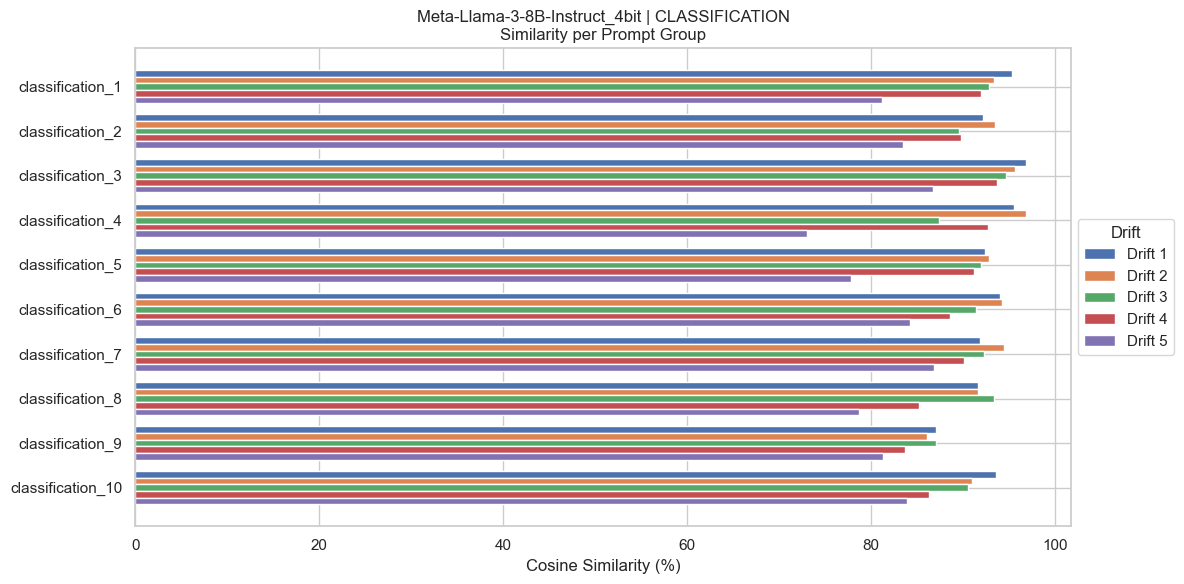

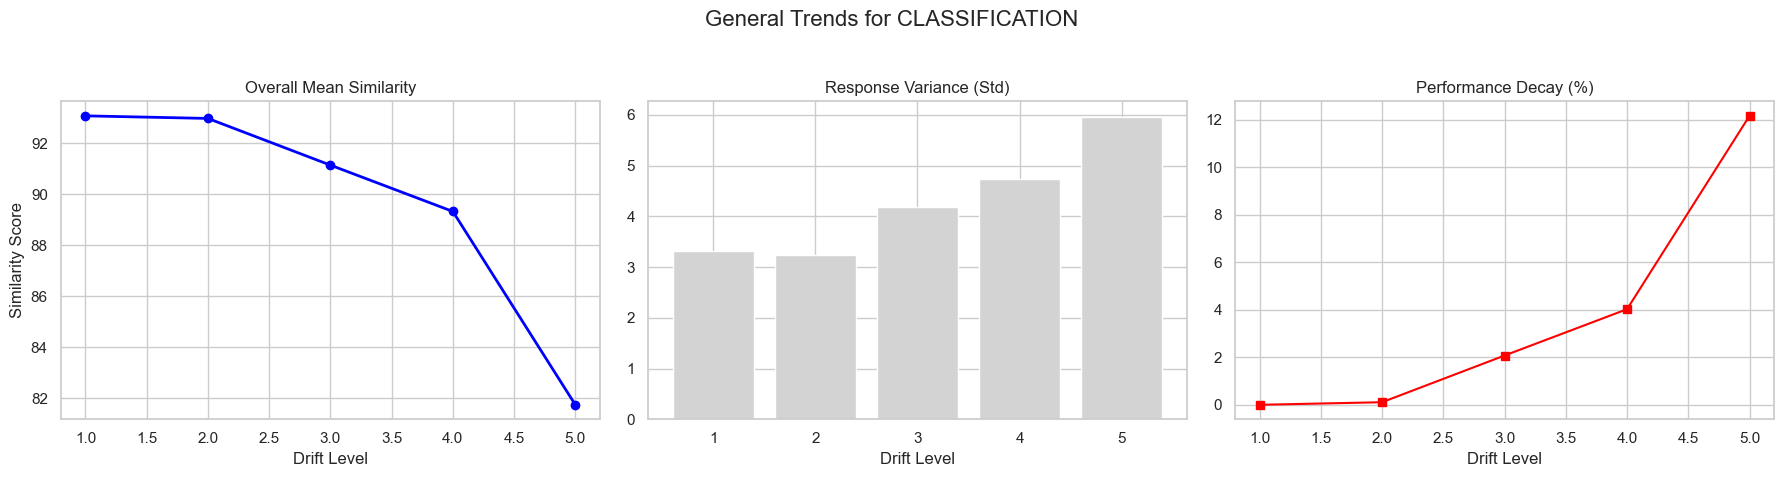

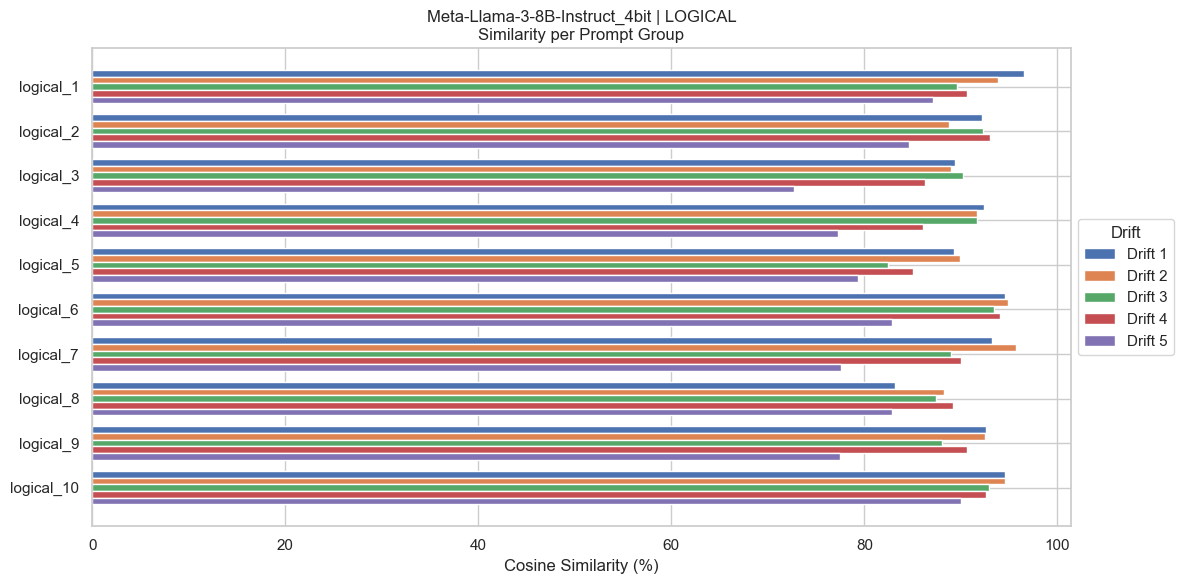

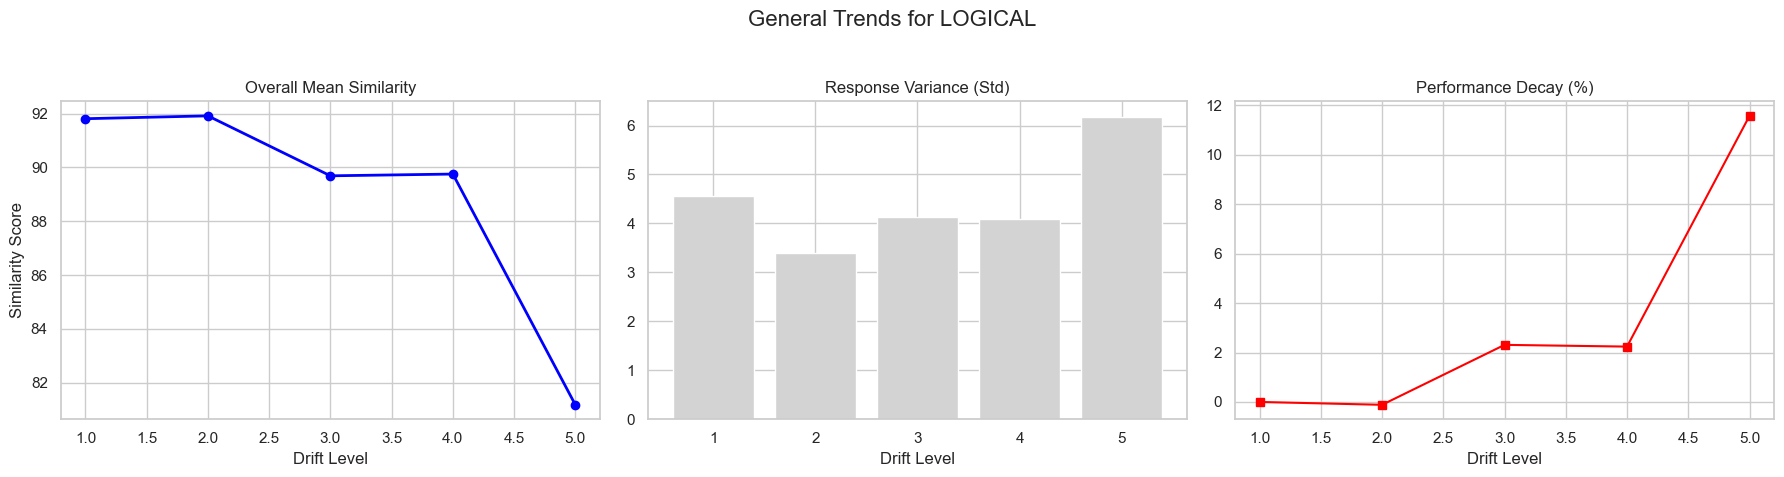

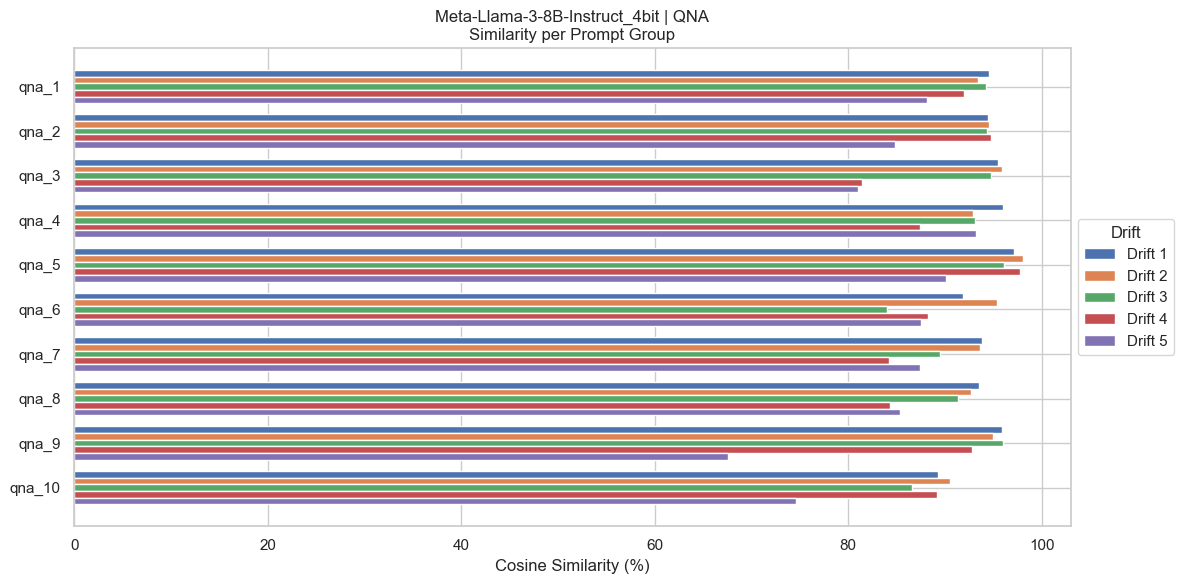

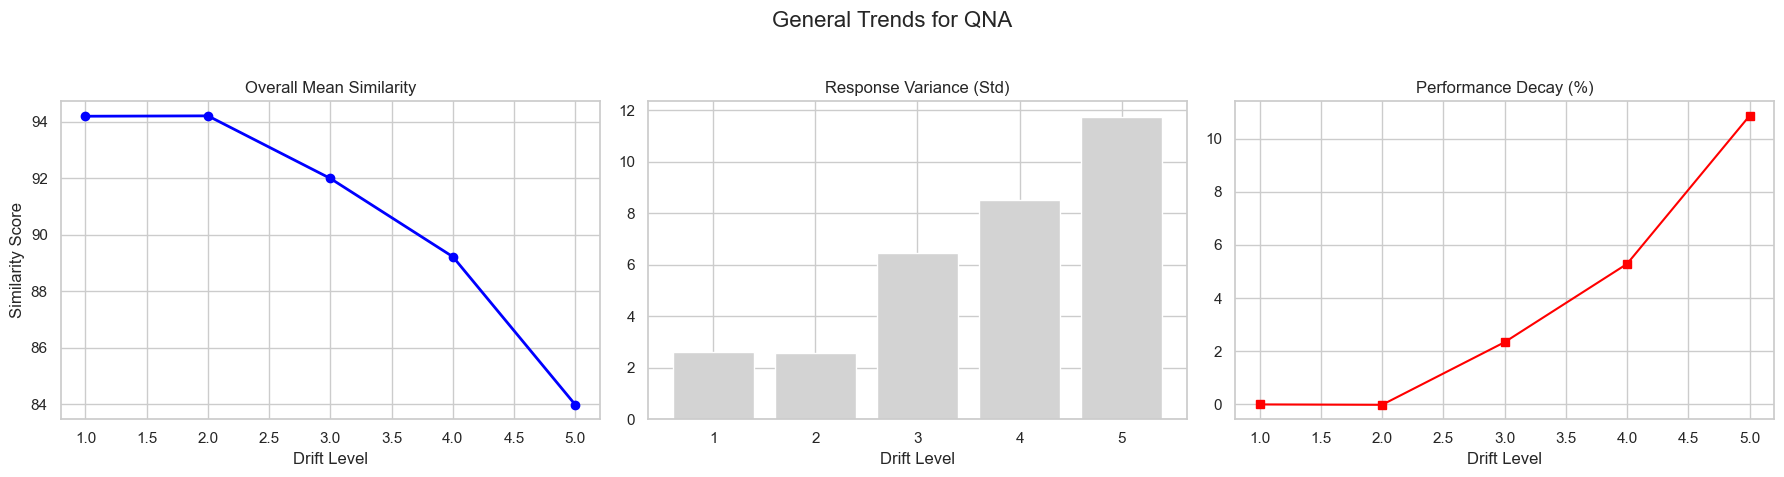

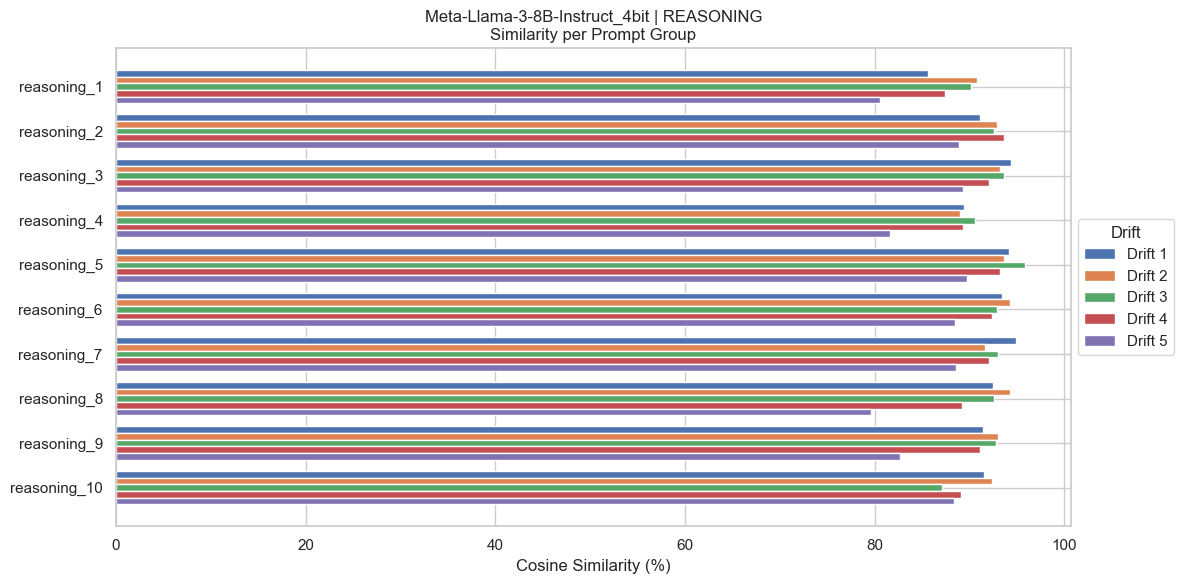

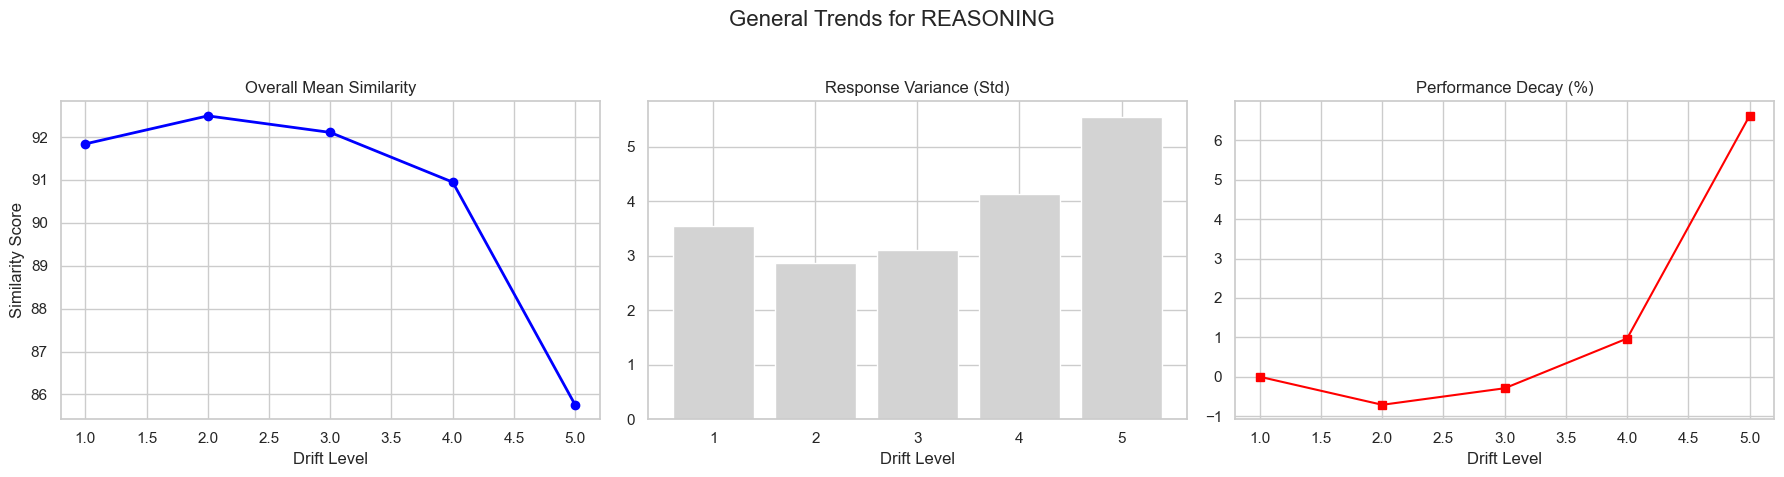


--- Summary Heatmap for Meta-Llama-3-8B-Instruct_4bit ---


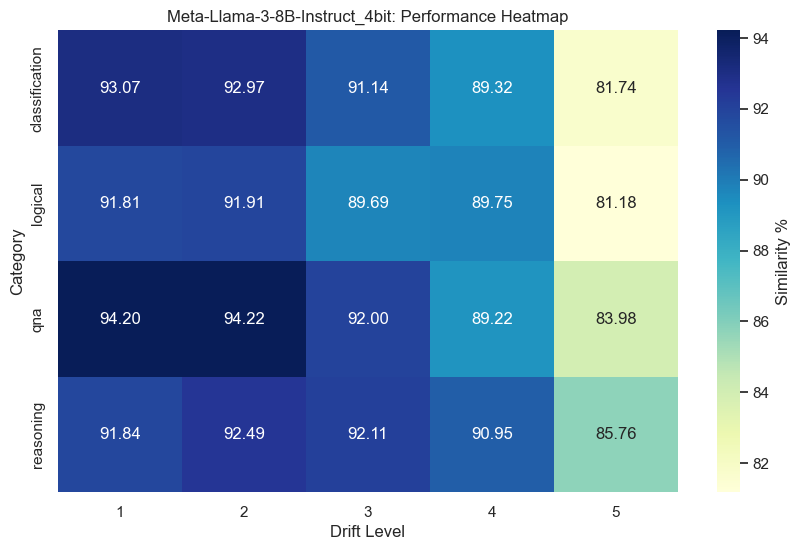


________________________________________________________________________________

##################### MODEL: Meta-Llama-3-8B-Instruct_8bit #####################


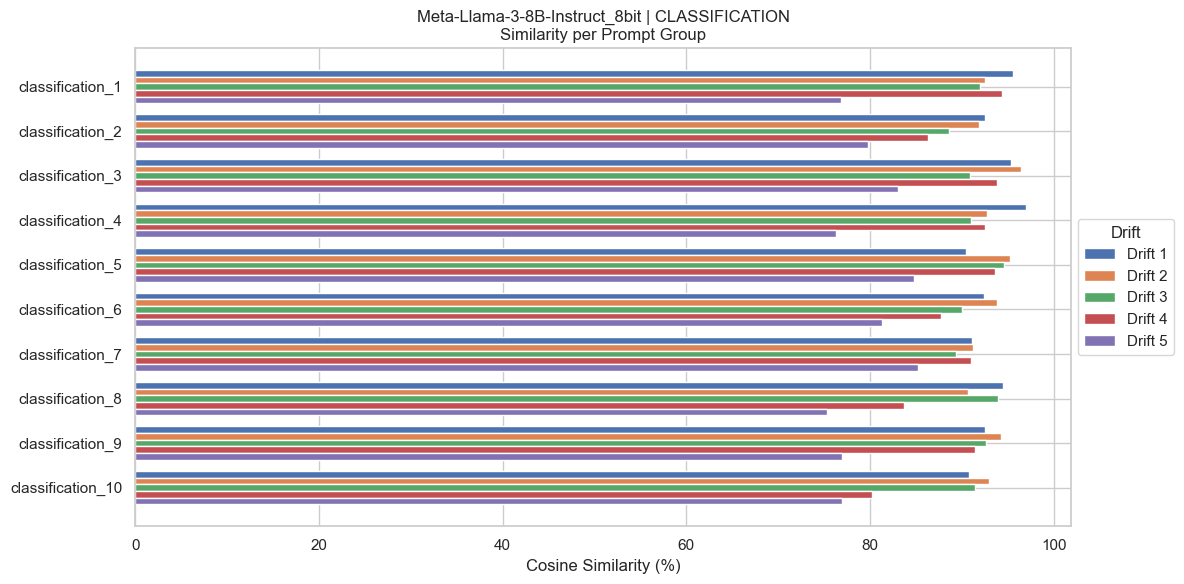

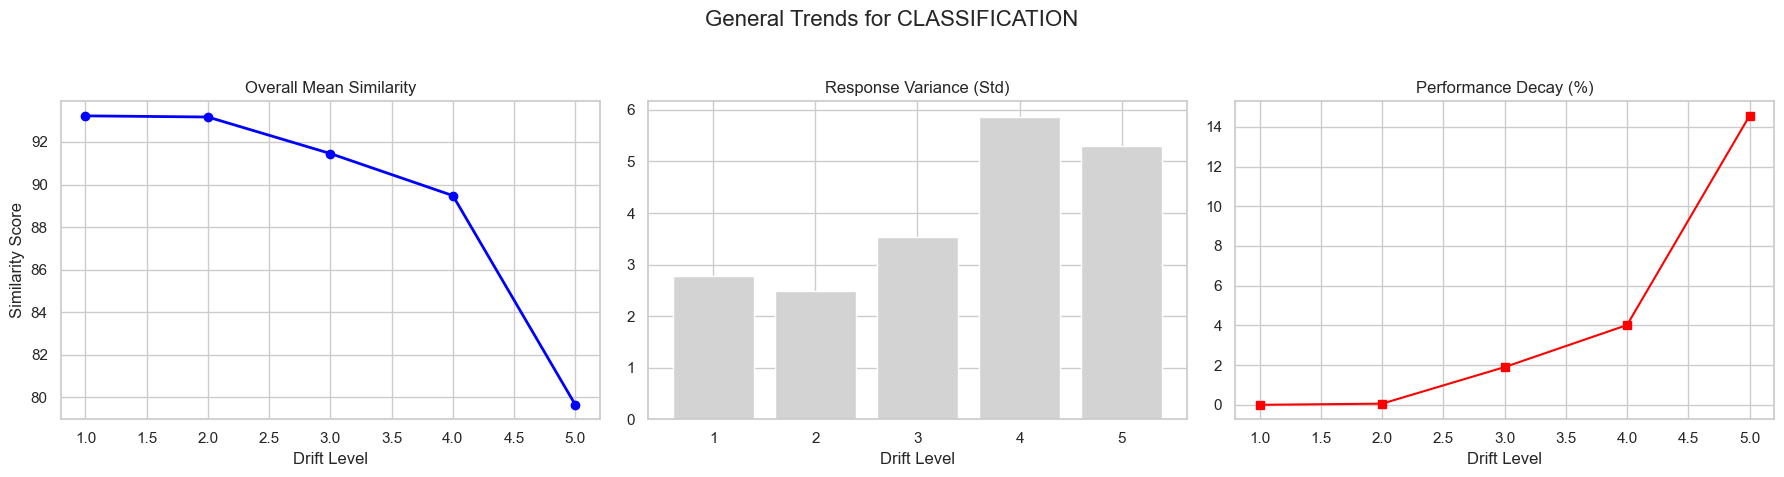

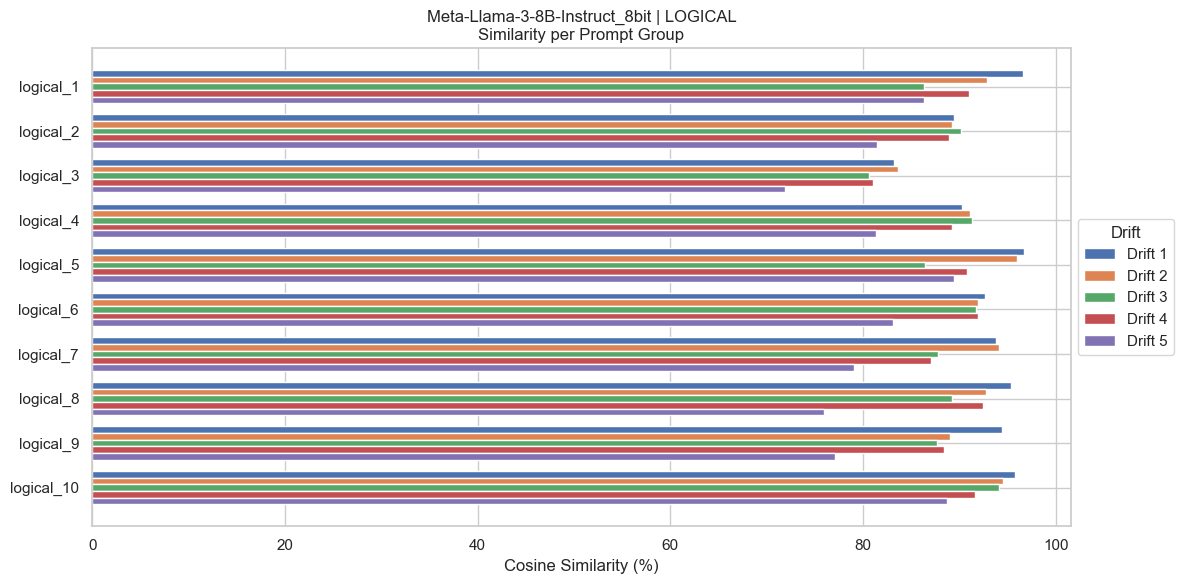

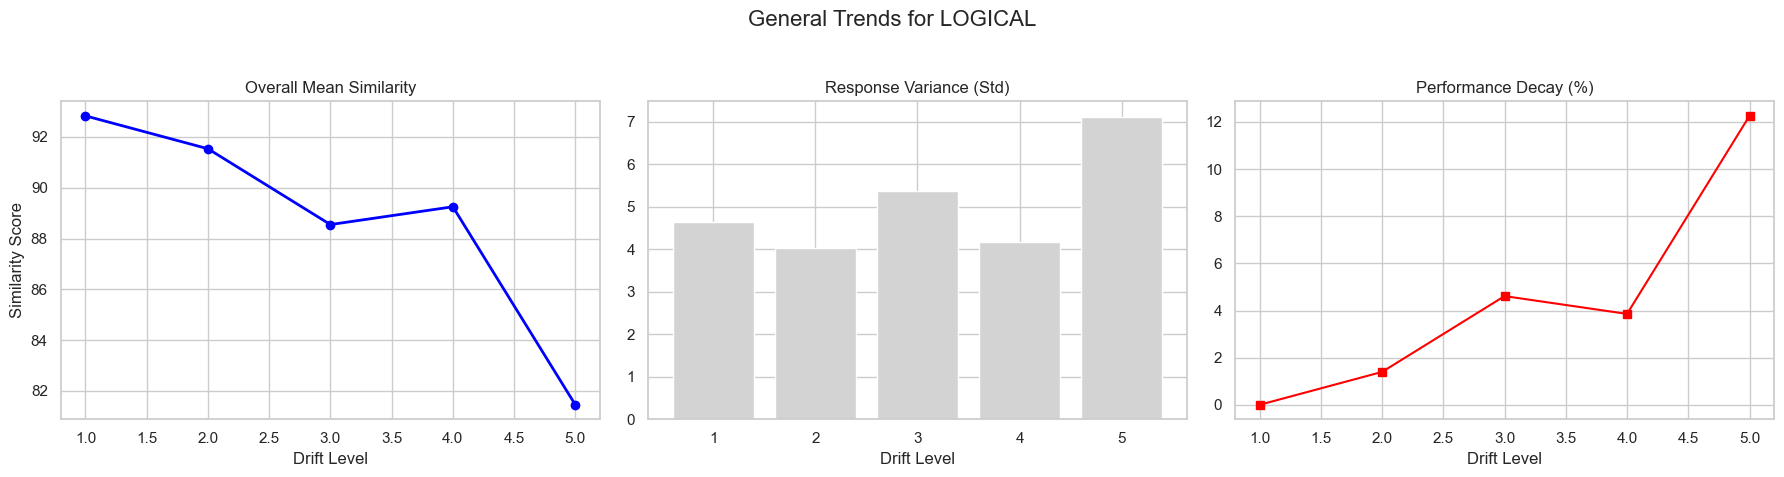

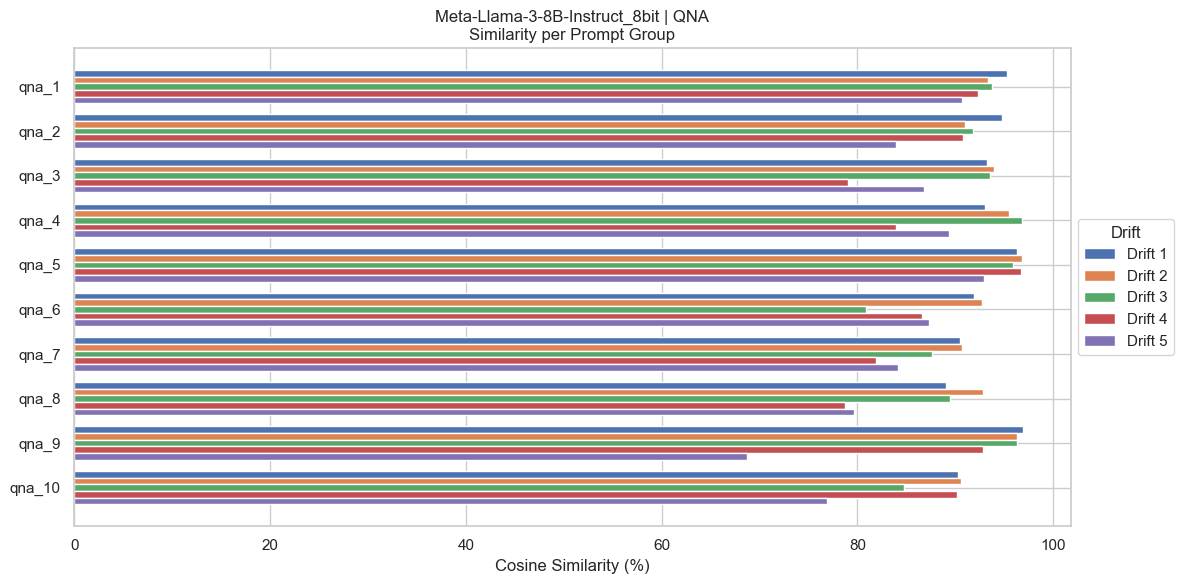

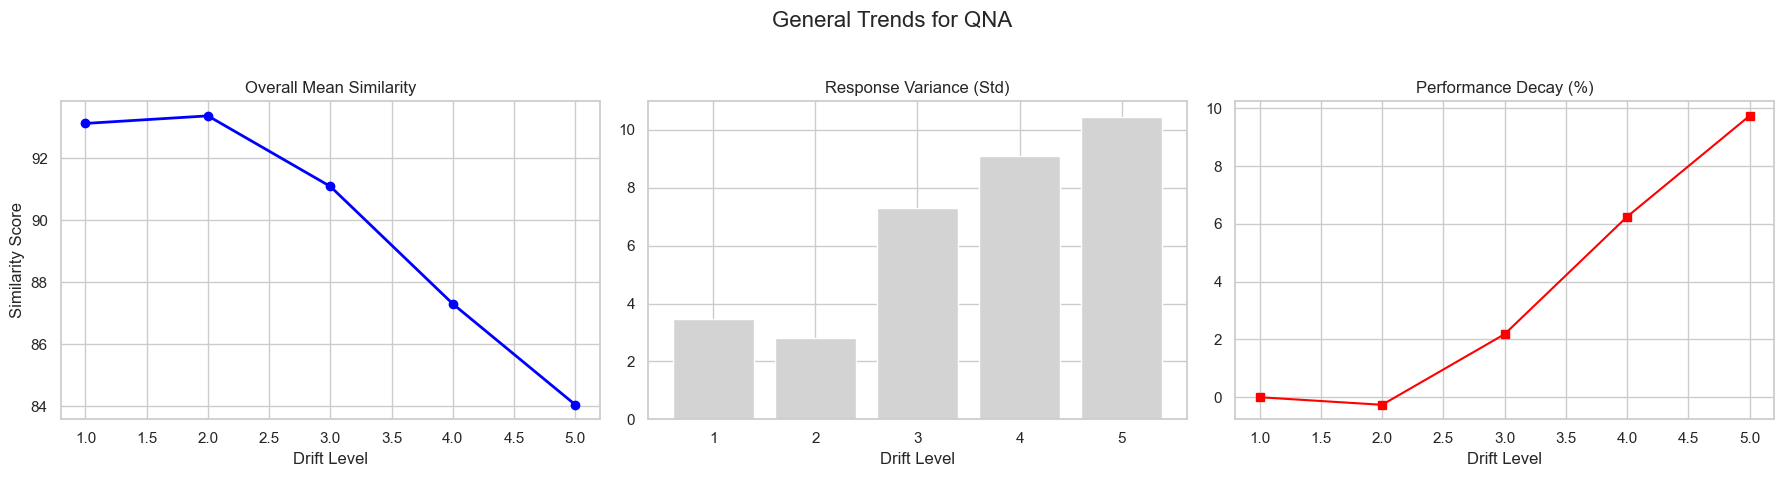

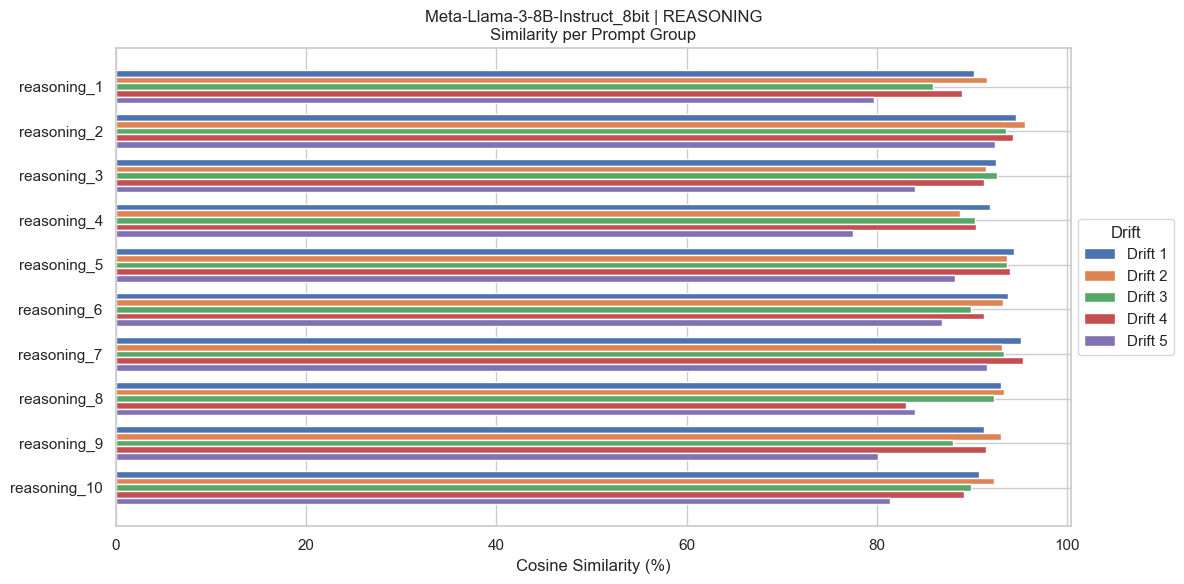

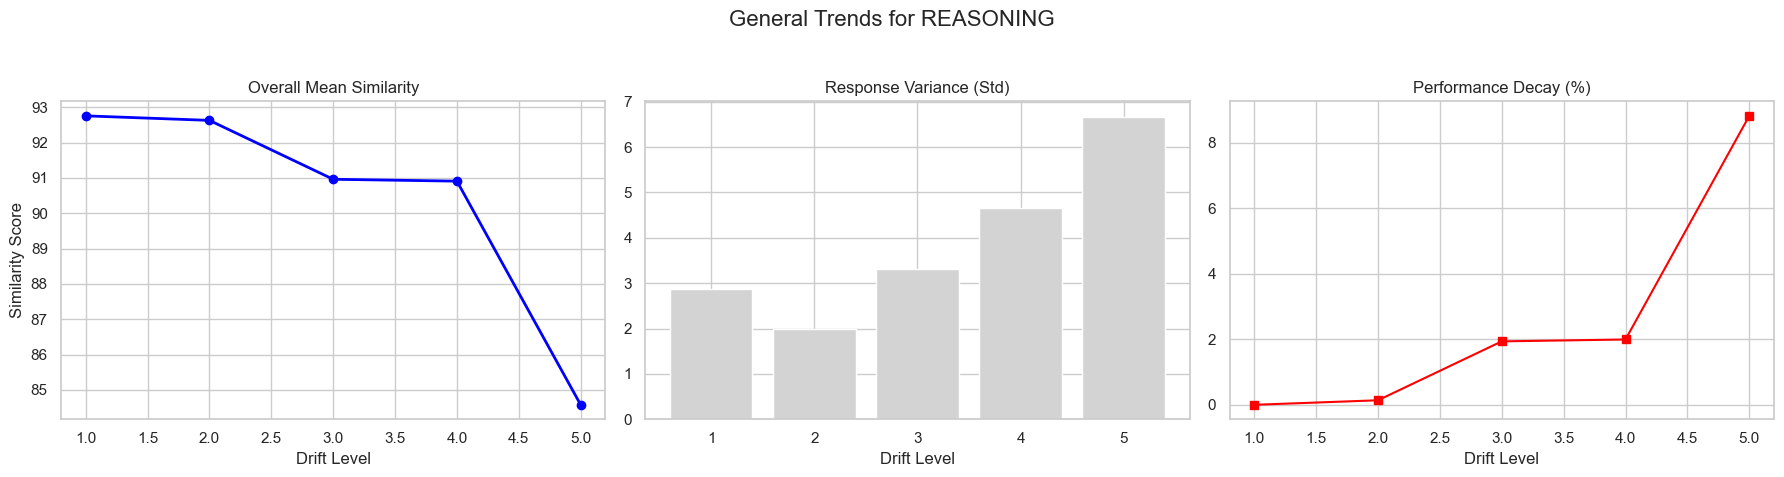


--- Summary Heatmap for Meta-Llama-3-8B-Instruct_8bit ---


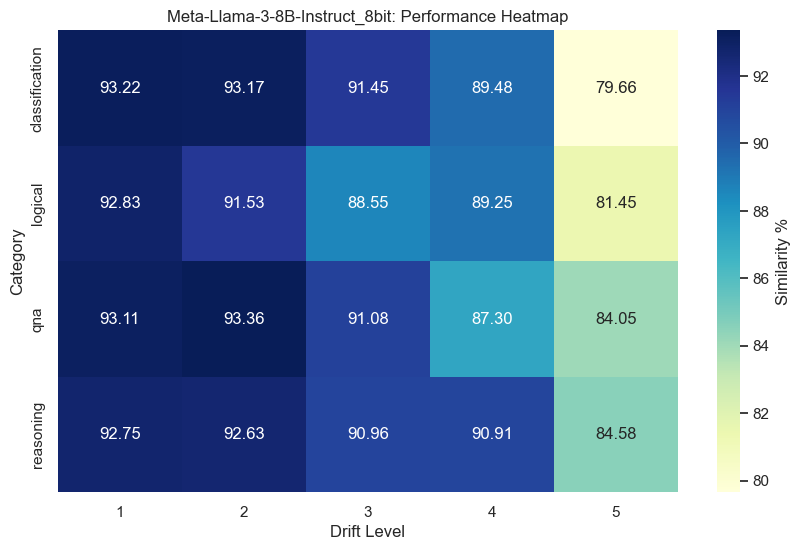


________________________________________________________________________________

##################### MODEL: Meta-Llama-3-8B-Instruct_fp16 #####################


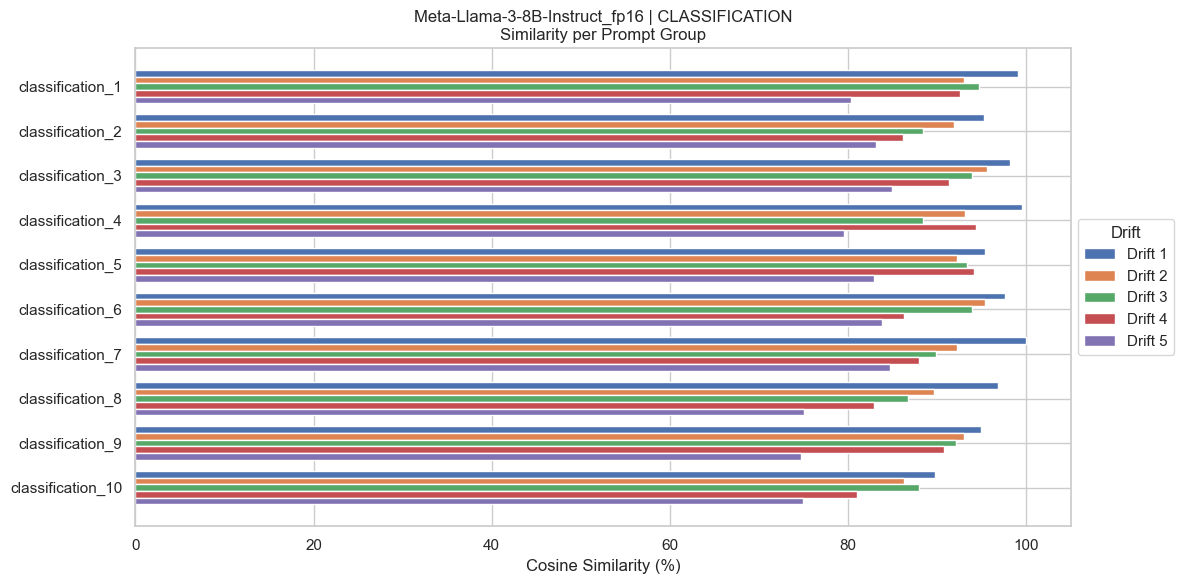

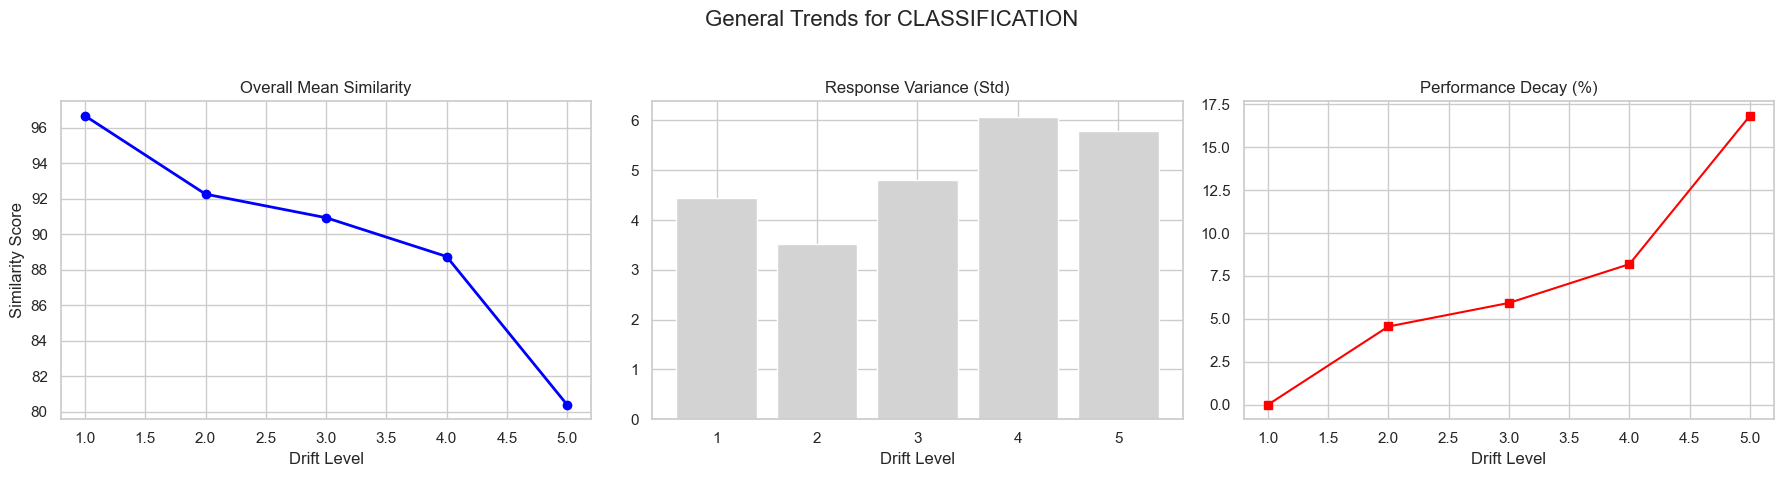

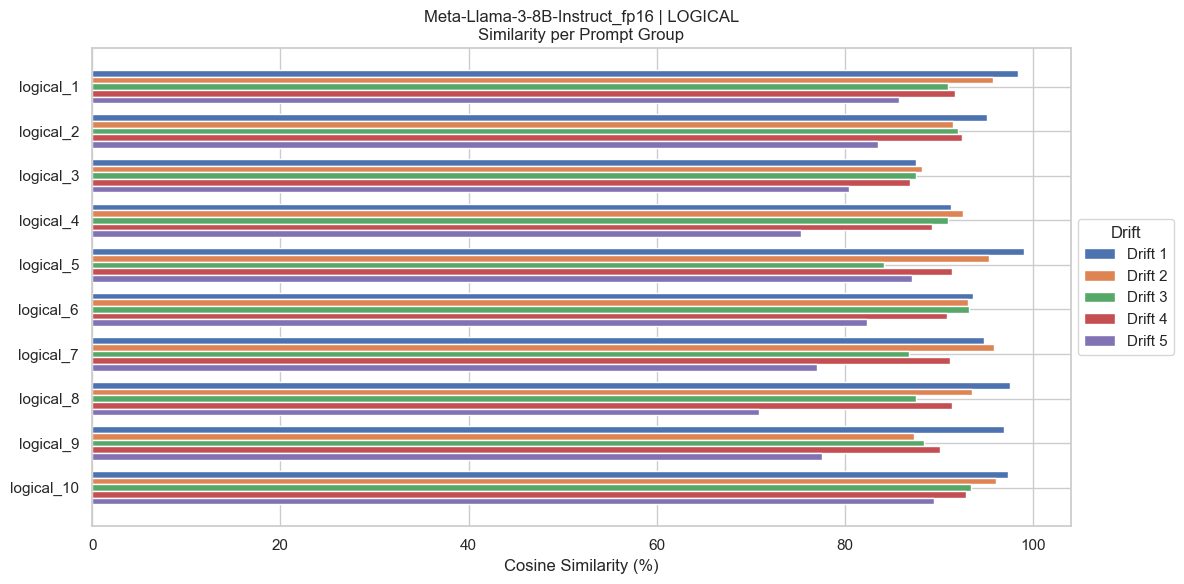

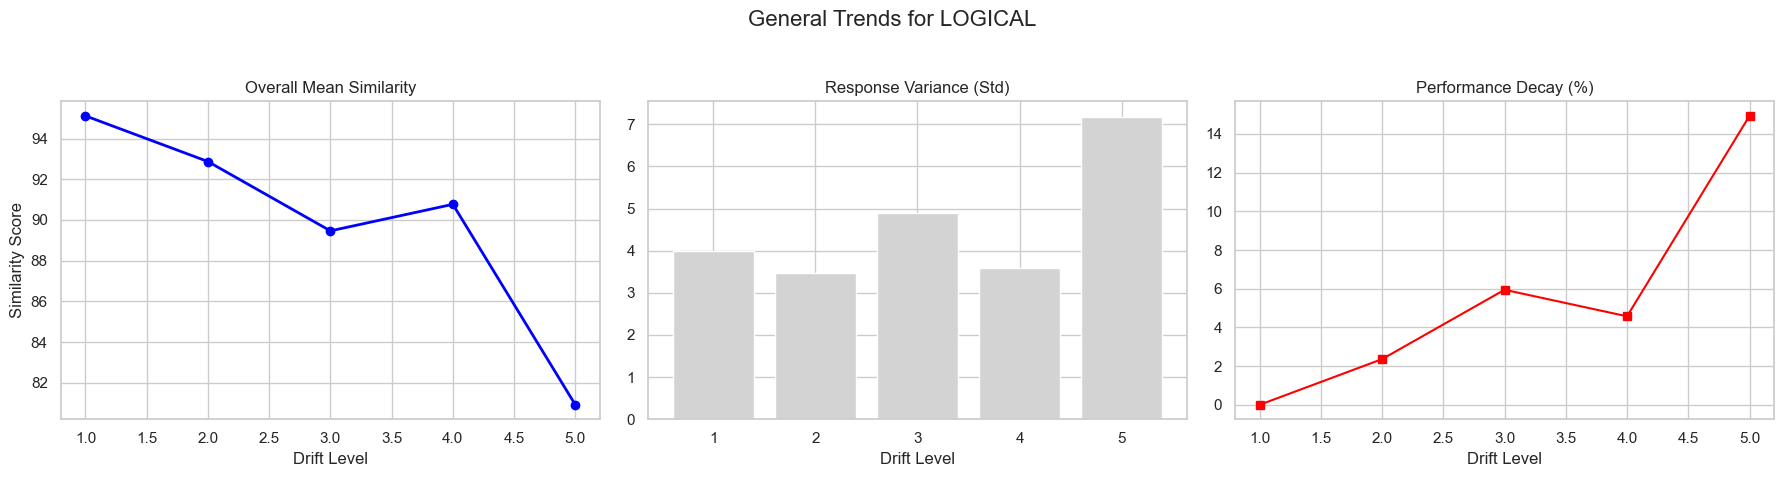

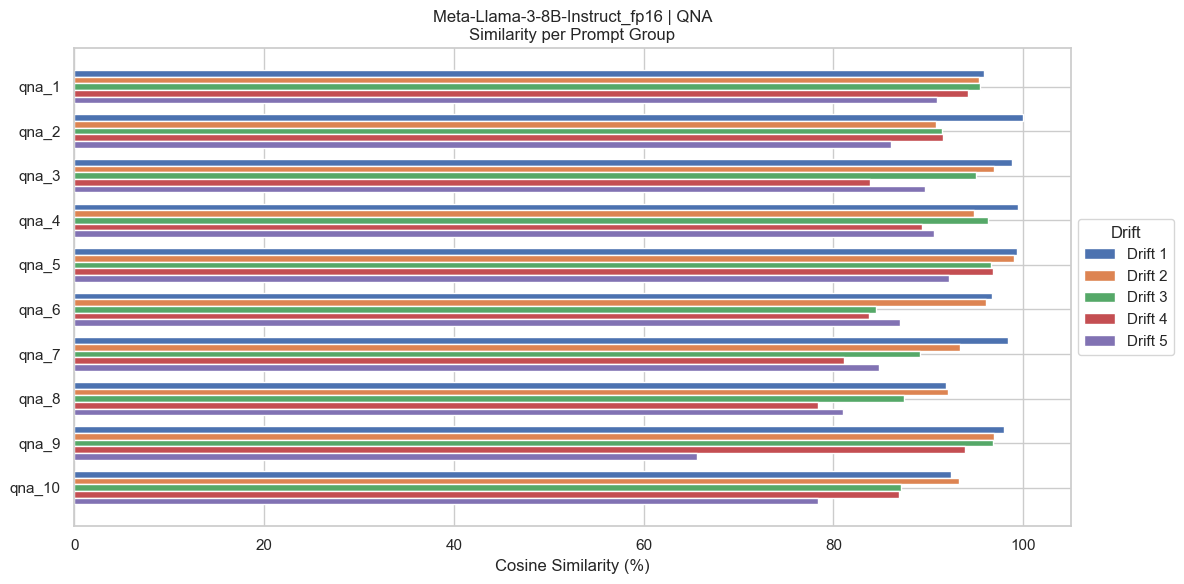

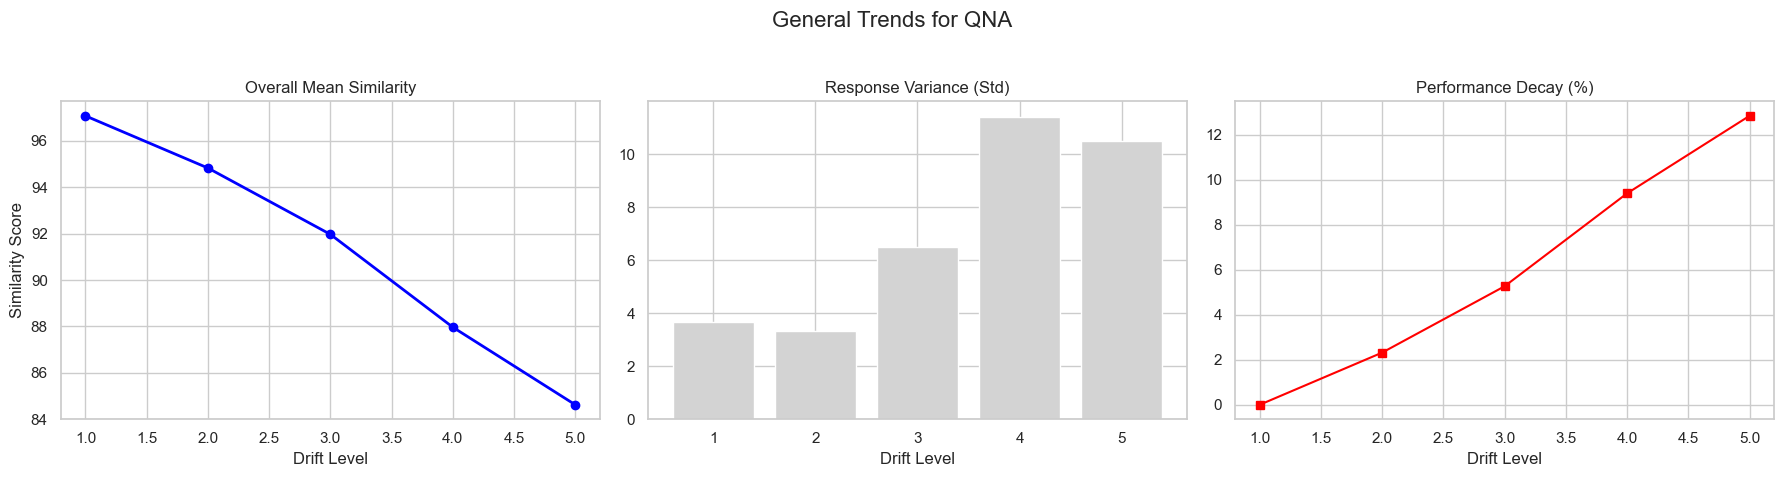

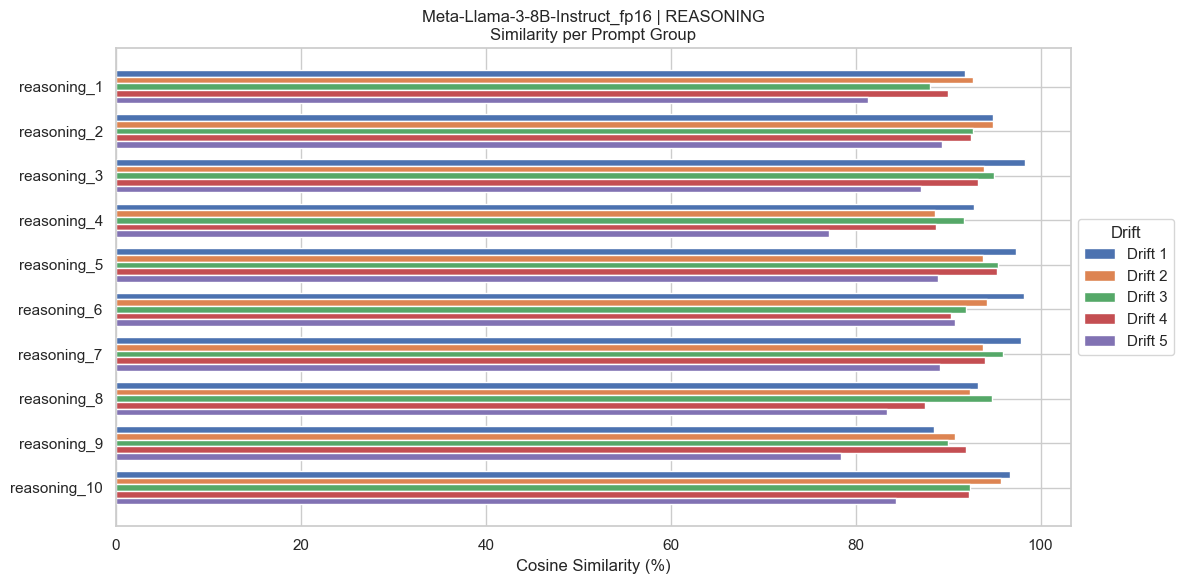

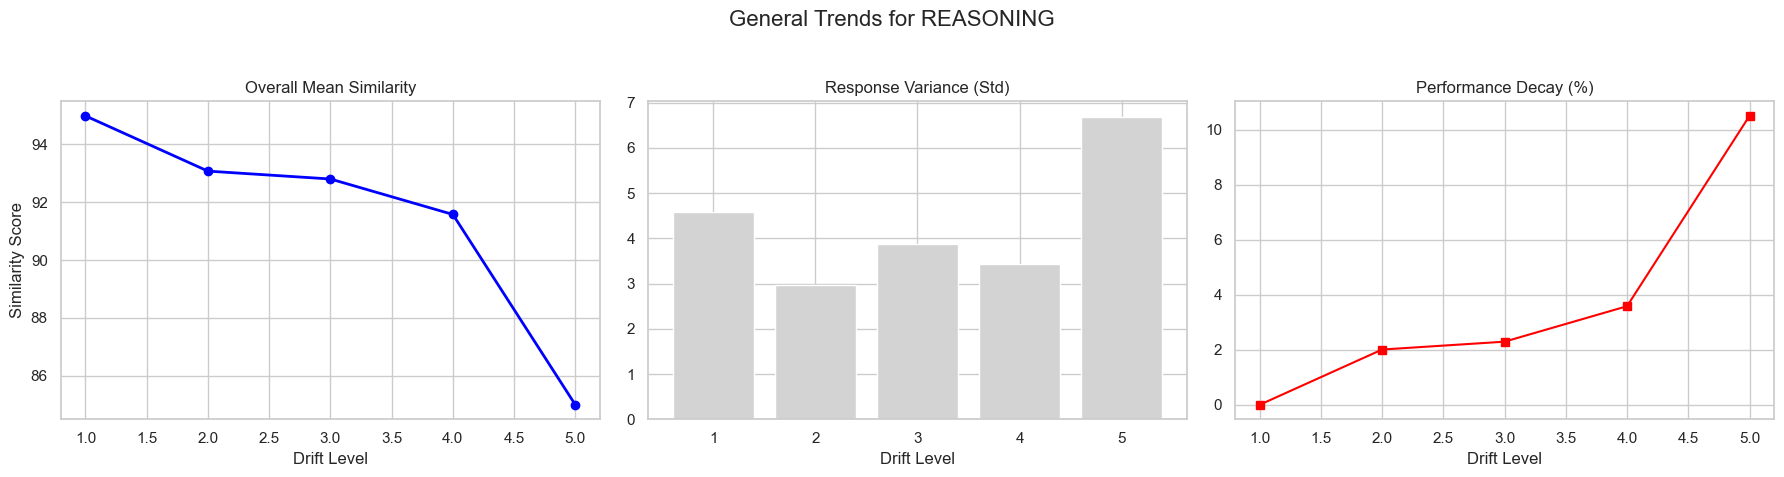


--- Summary Heatmap for Meta-Llama-3-8B-Instruct_fp16 ---


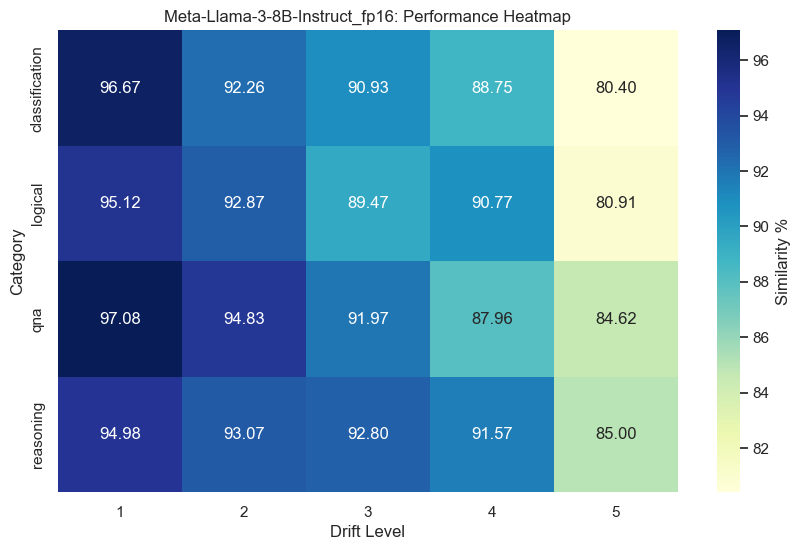


________________________________________________________________________________

###################### MODEL: Phi-3-mini-4k-instruct_4bit ######################


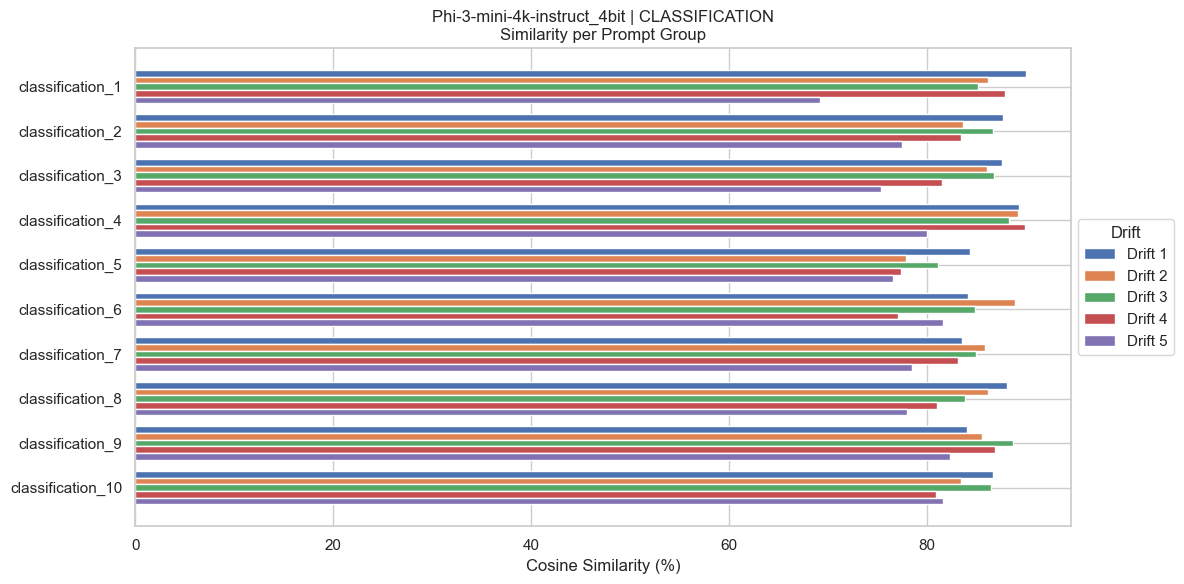

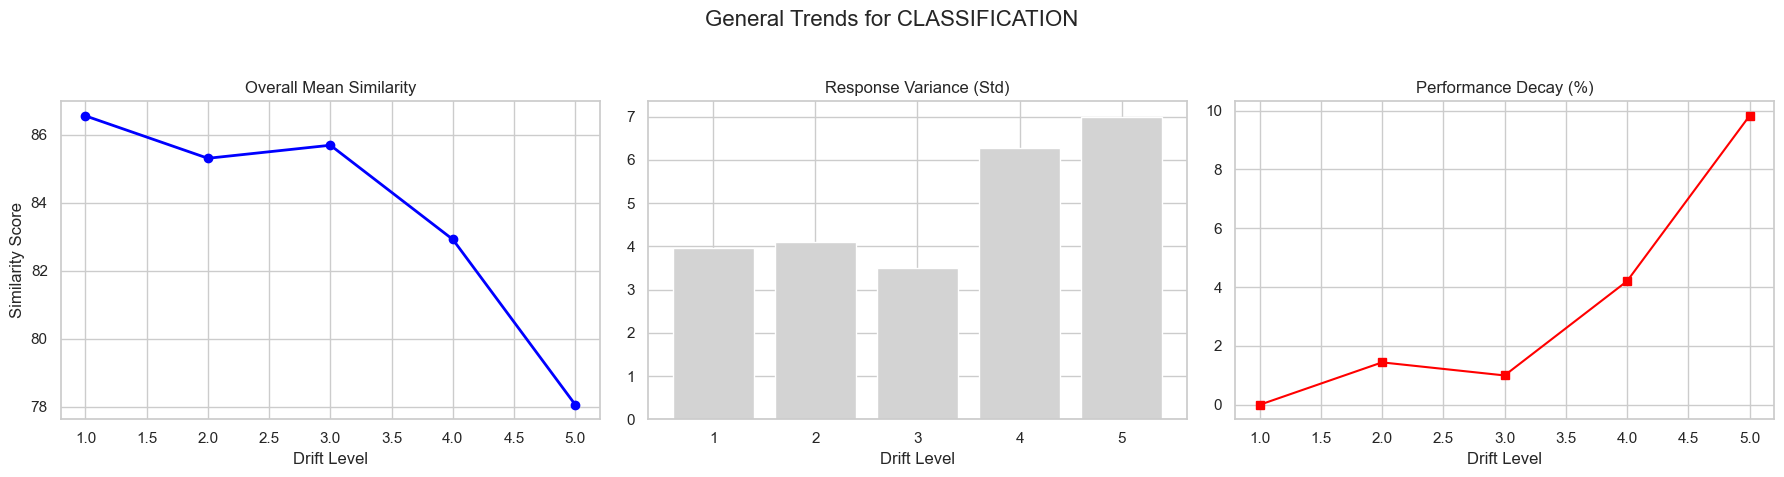

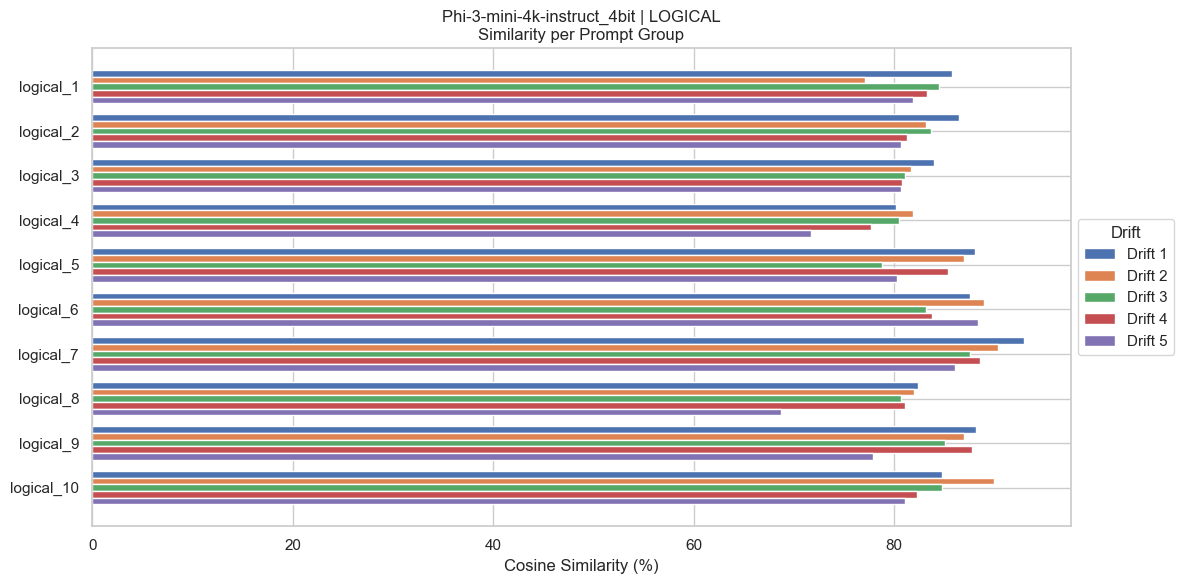

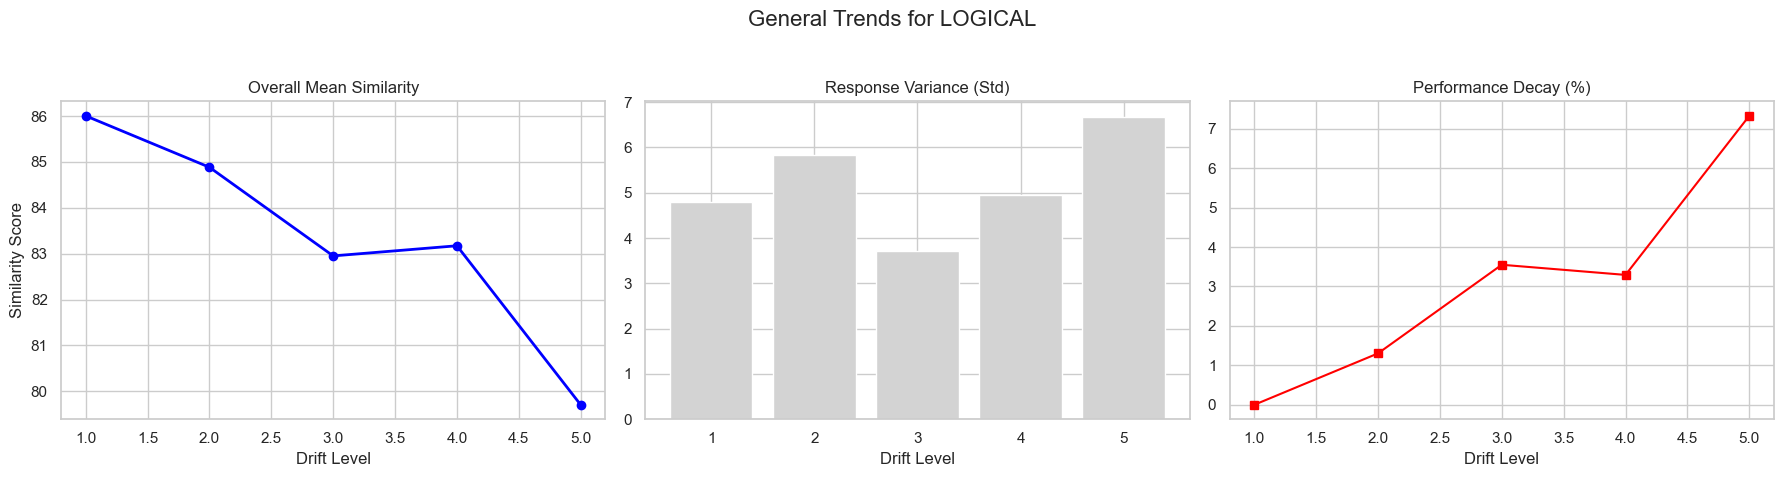

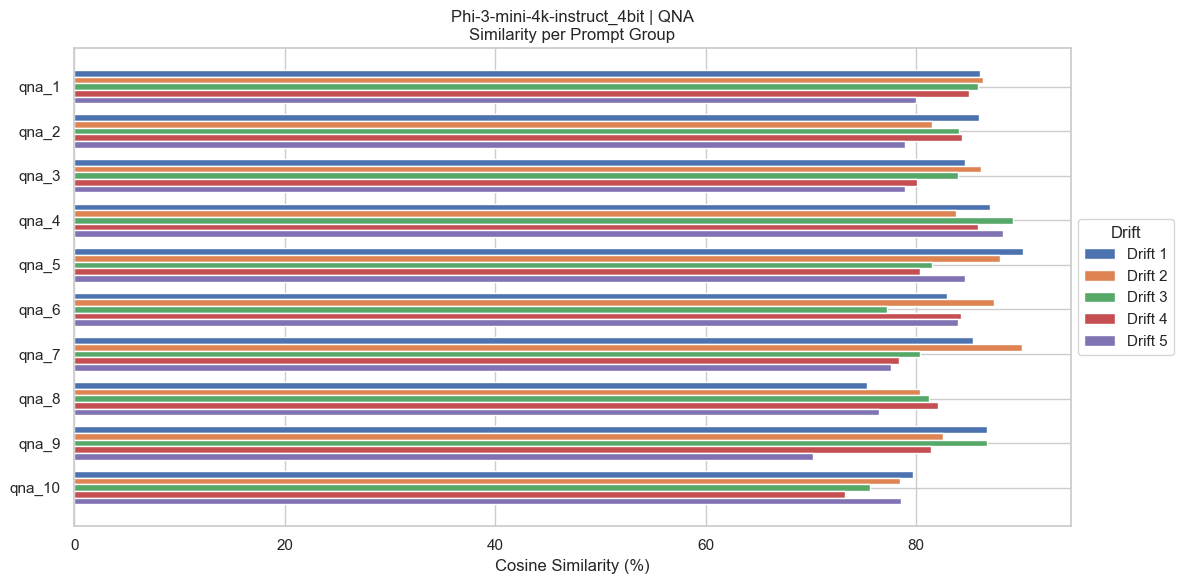

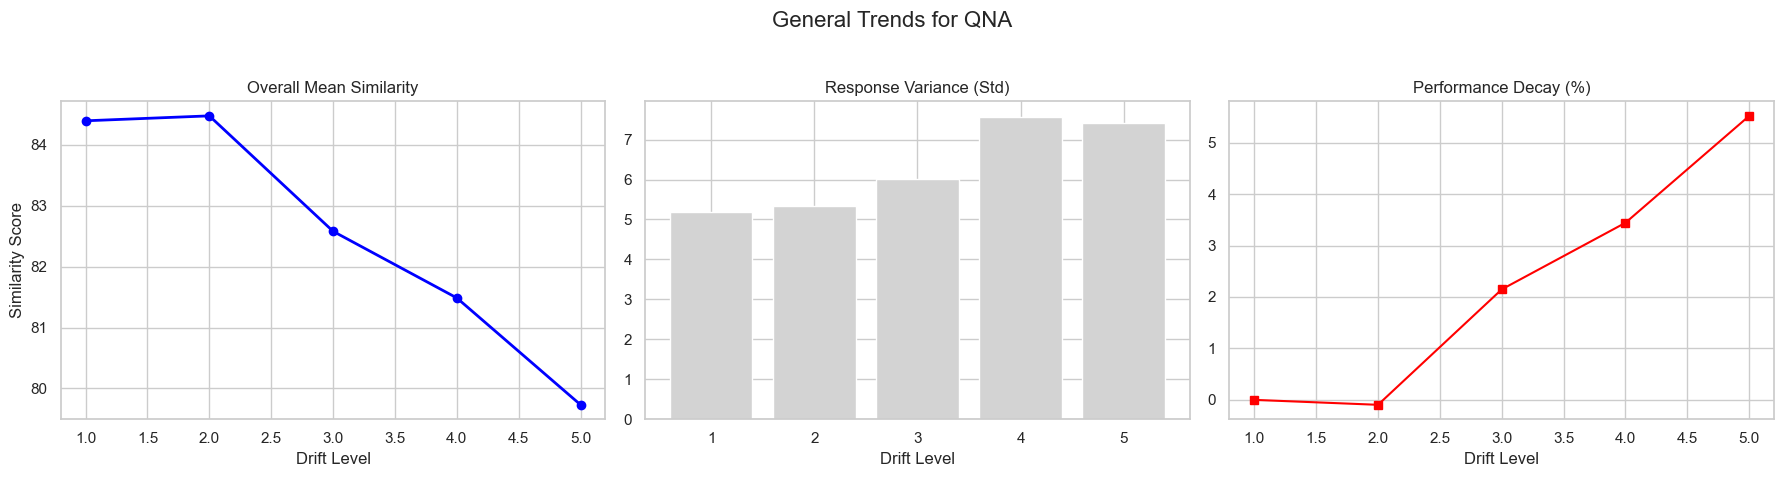

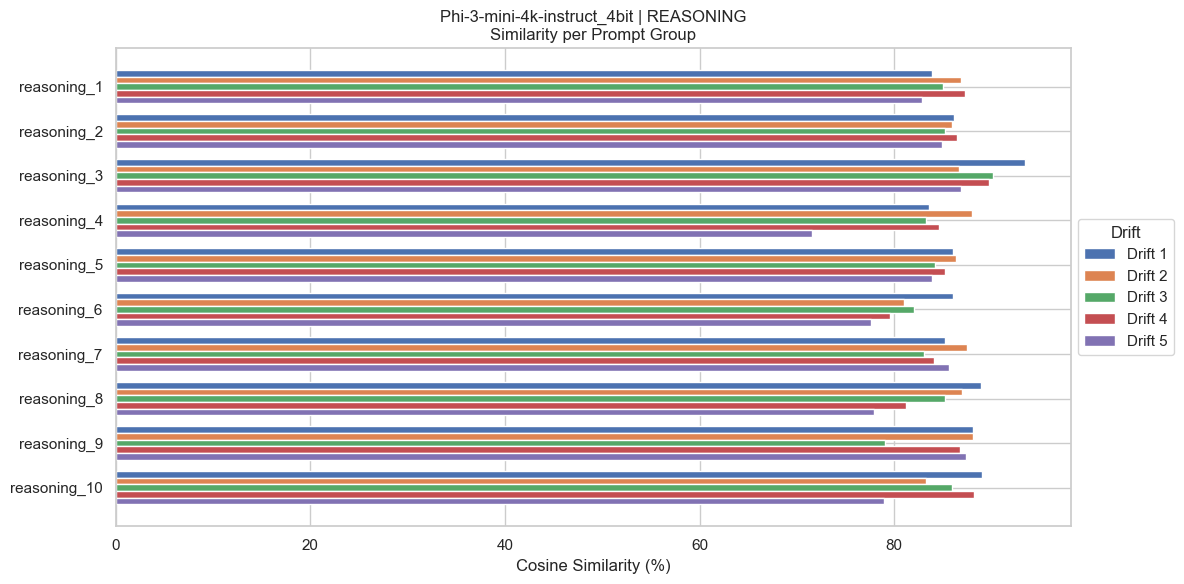

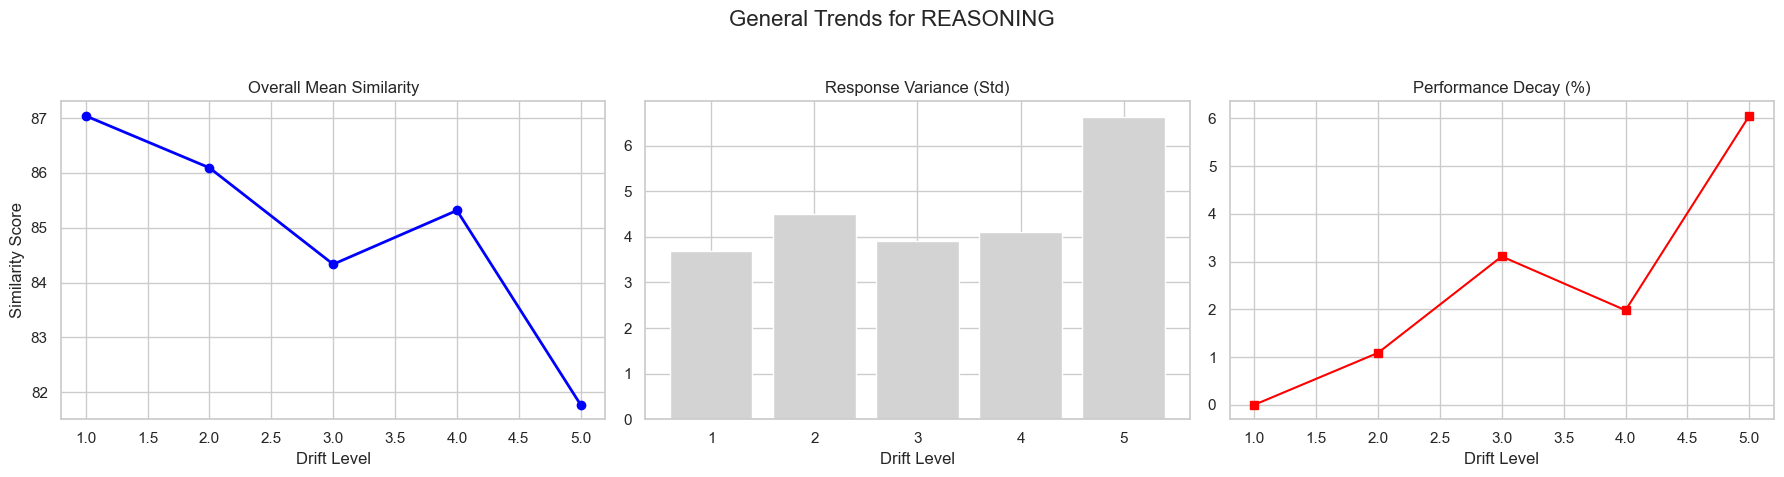


--- Summary Heatmap for Phi-3-mini-4k-instruct_4bit ---


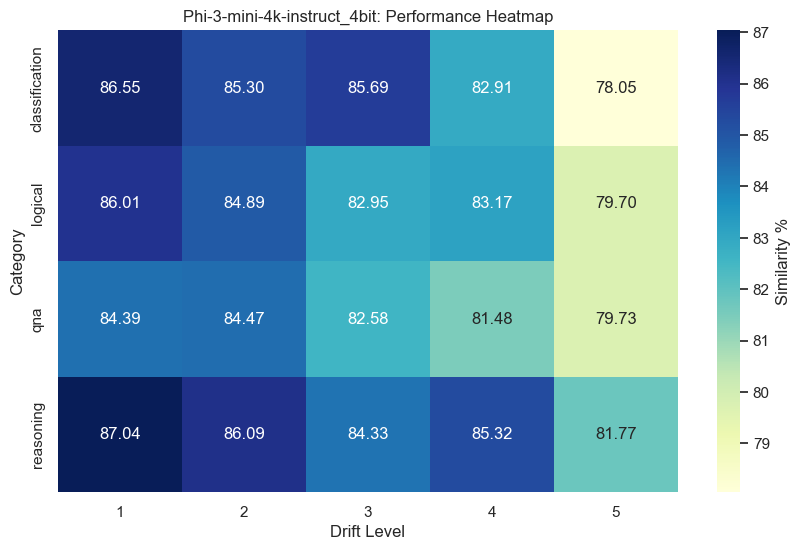


________________________________________________________________________________

###################### MODEL: Phi-3-mini-4k-instruct_8bit ######################


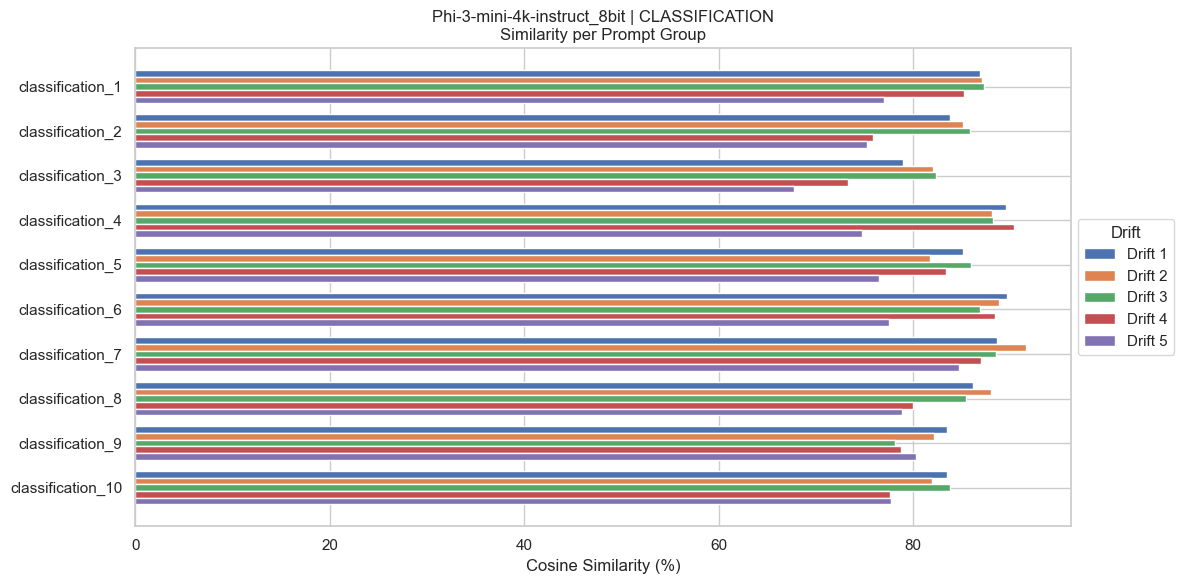

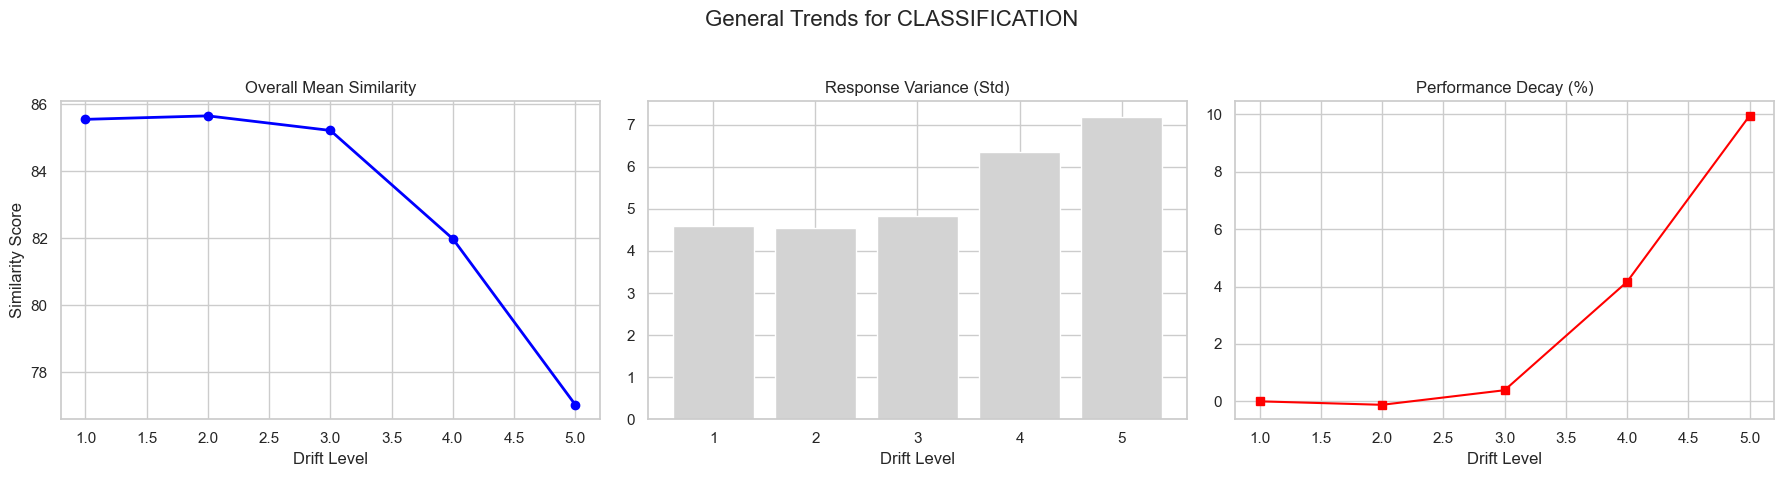

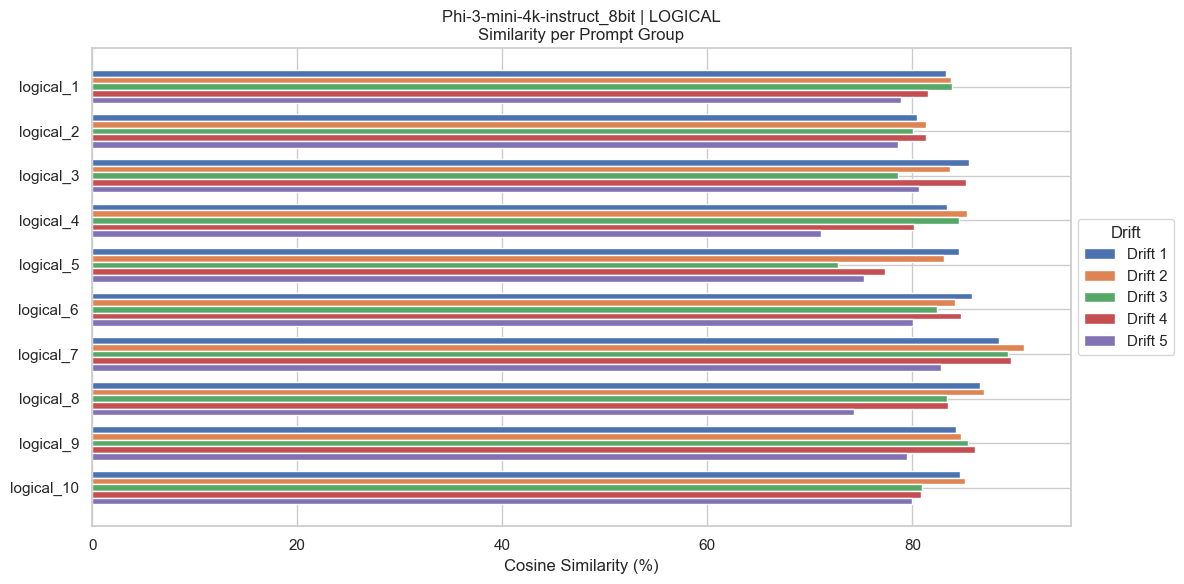

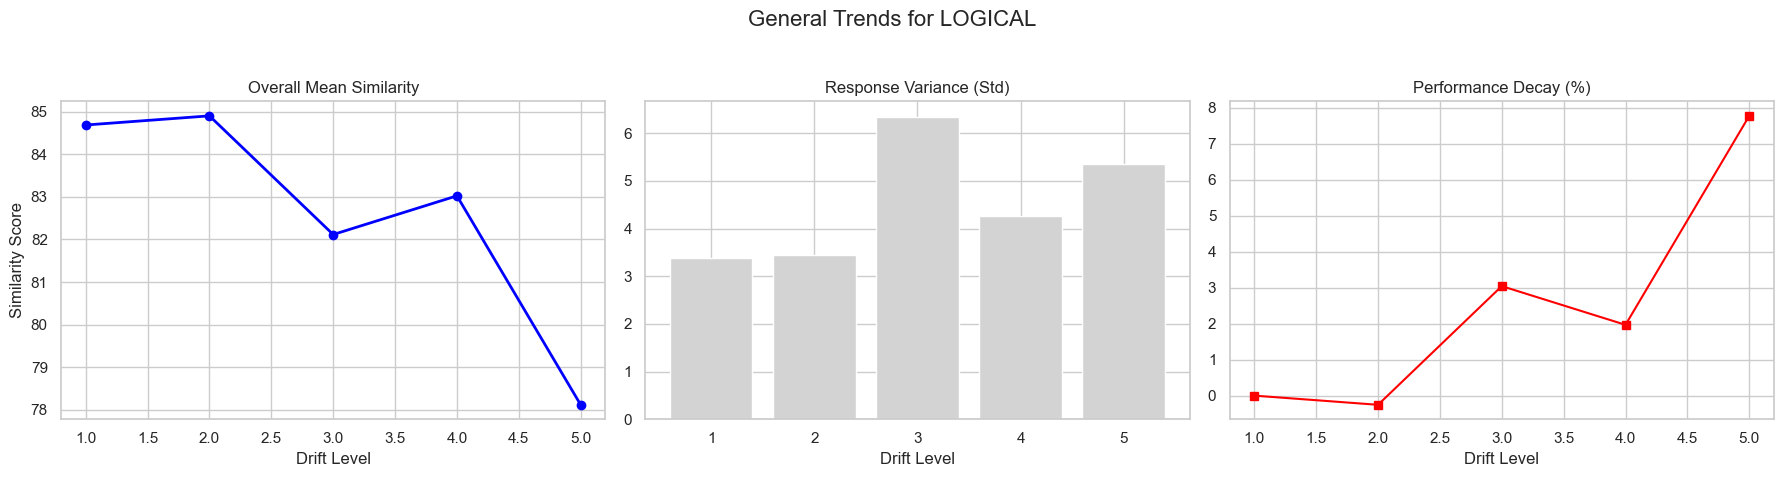

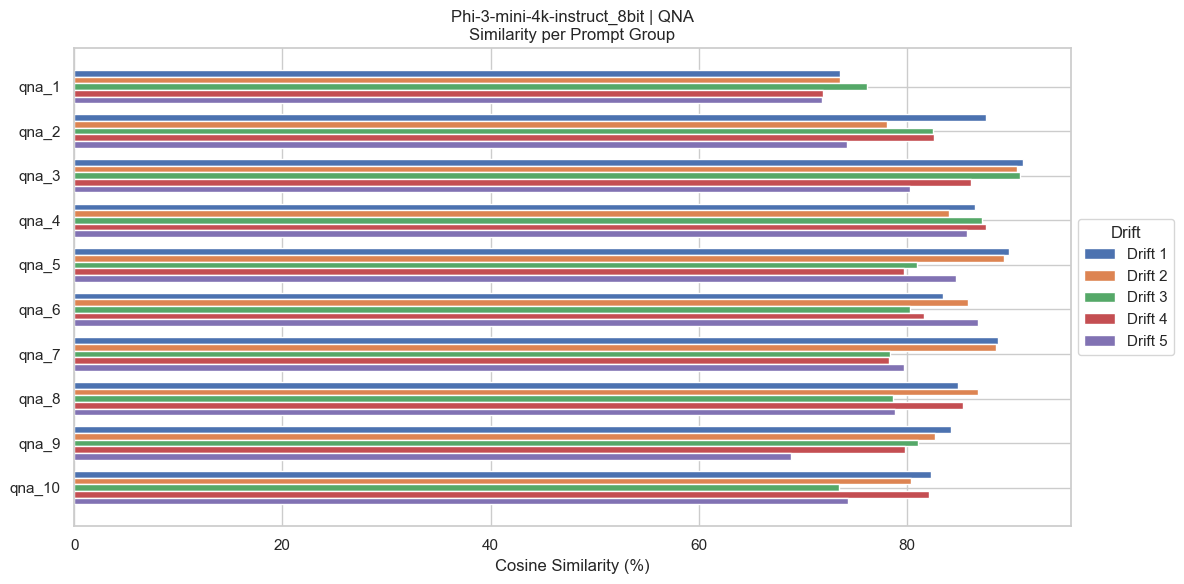

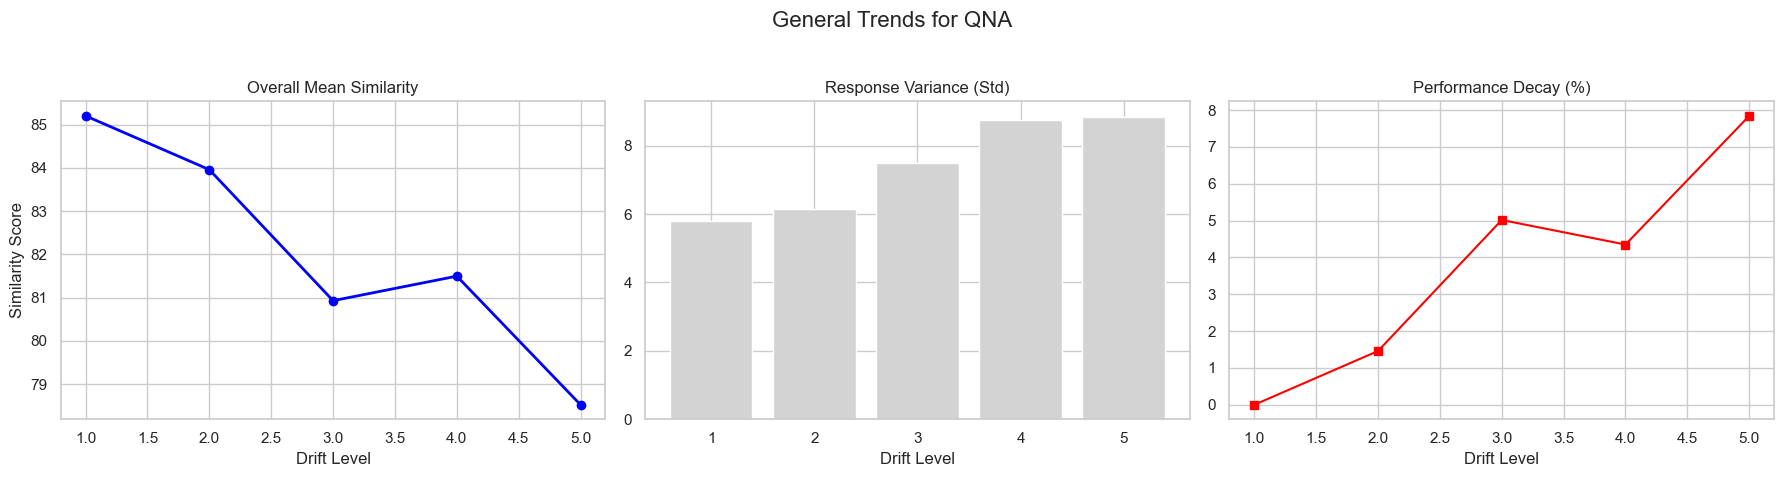

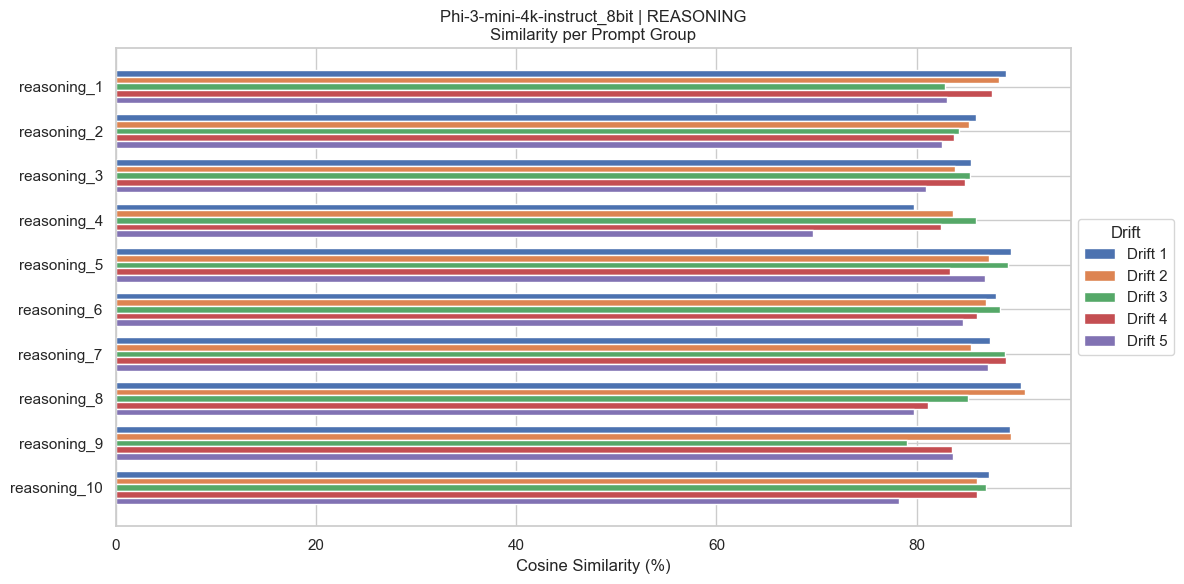

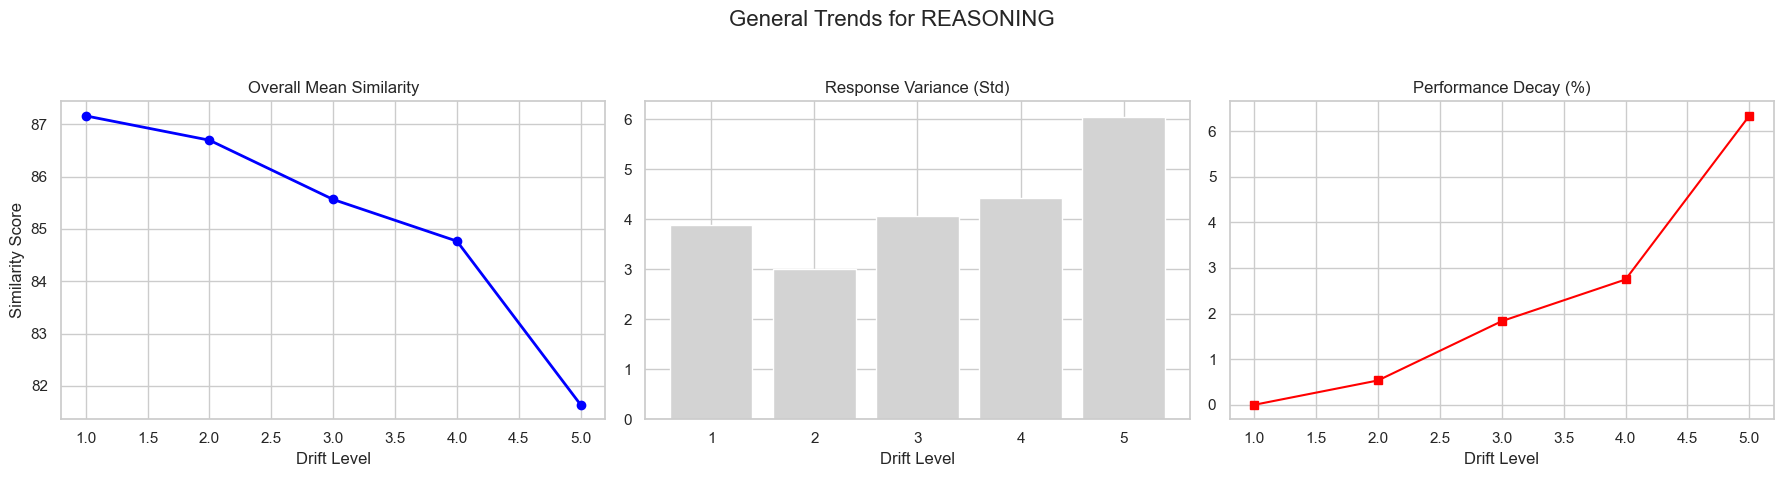


--- Summary Heatmap for Phi-3-mini-4k-instruct_8bit ---


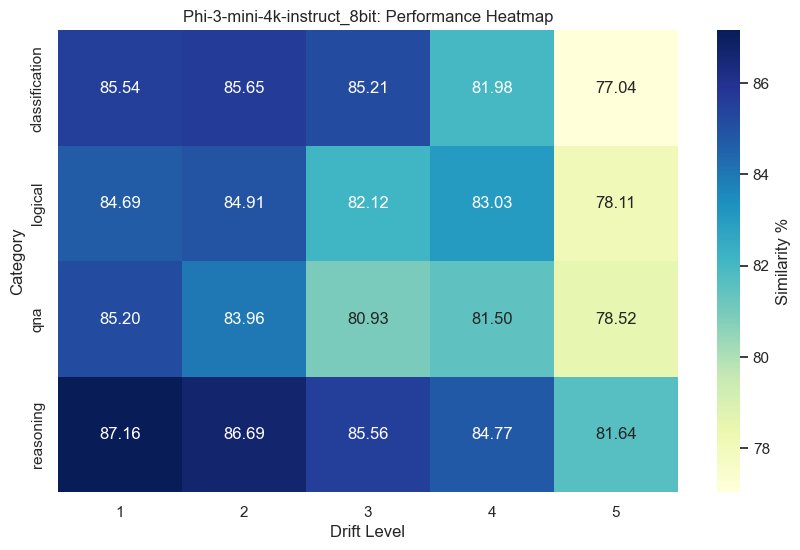


________________________________________________________________________________

###################### MODEL: Phi-3-mini-4k-instruct_fp16 ######################


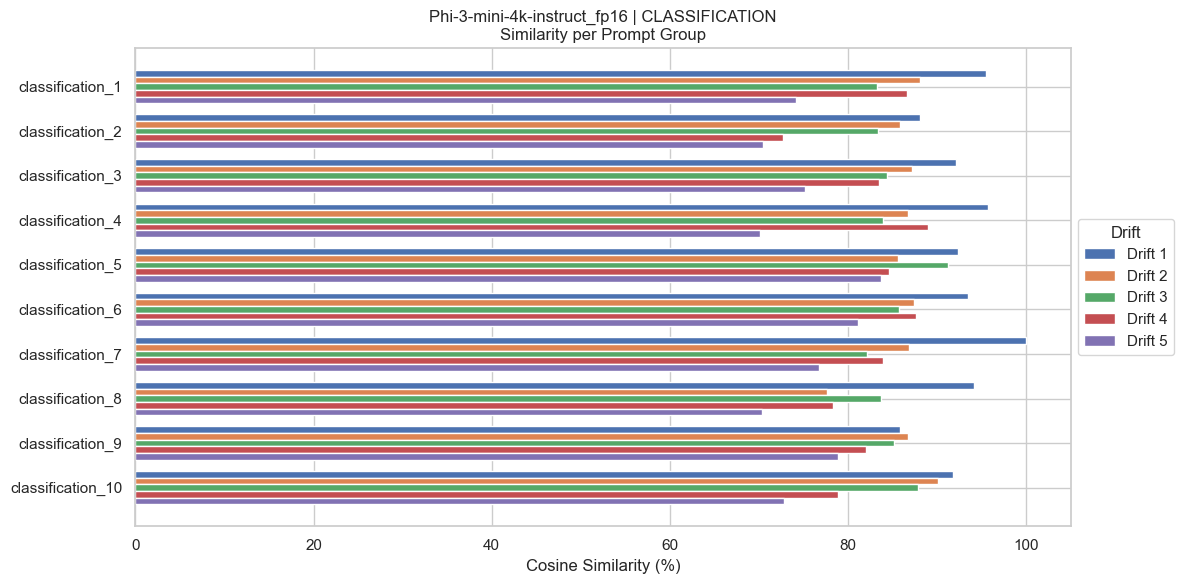

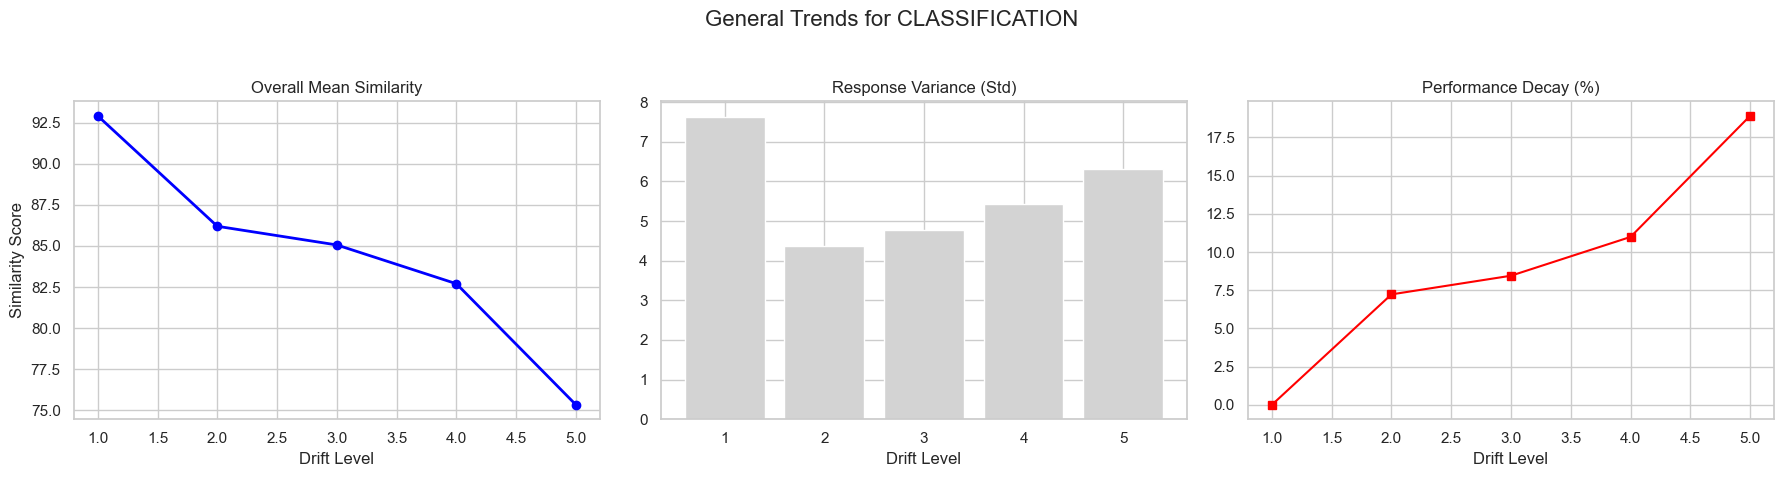

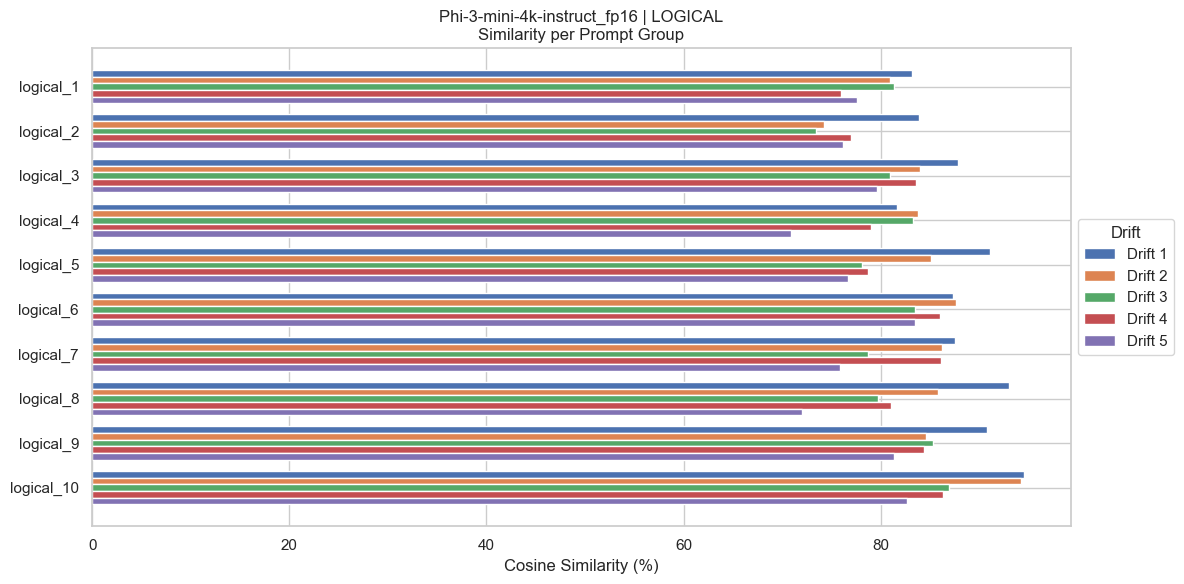

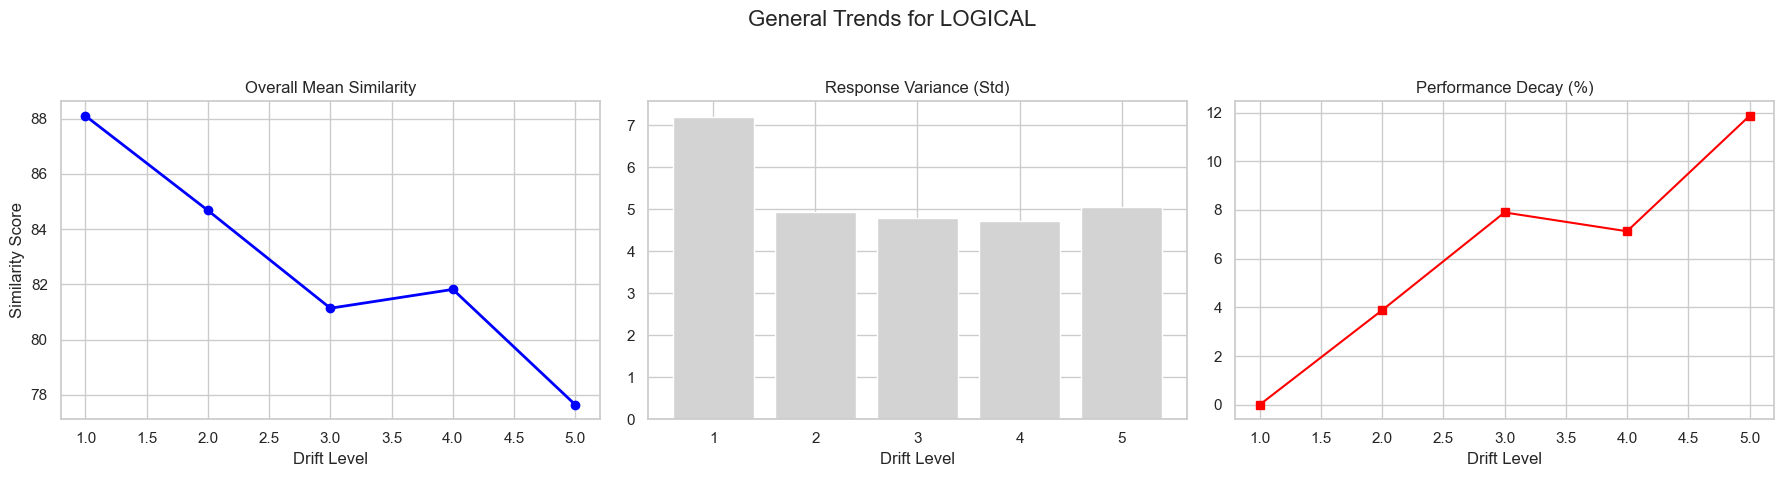

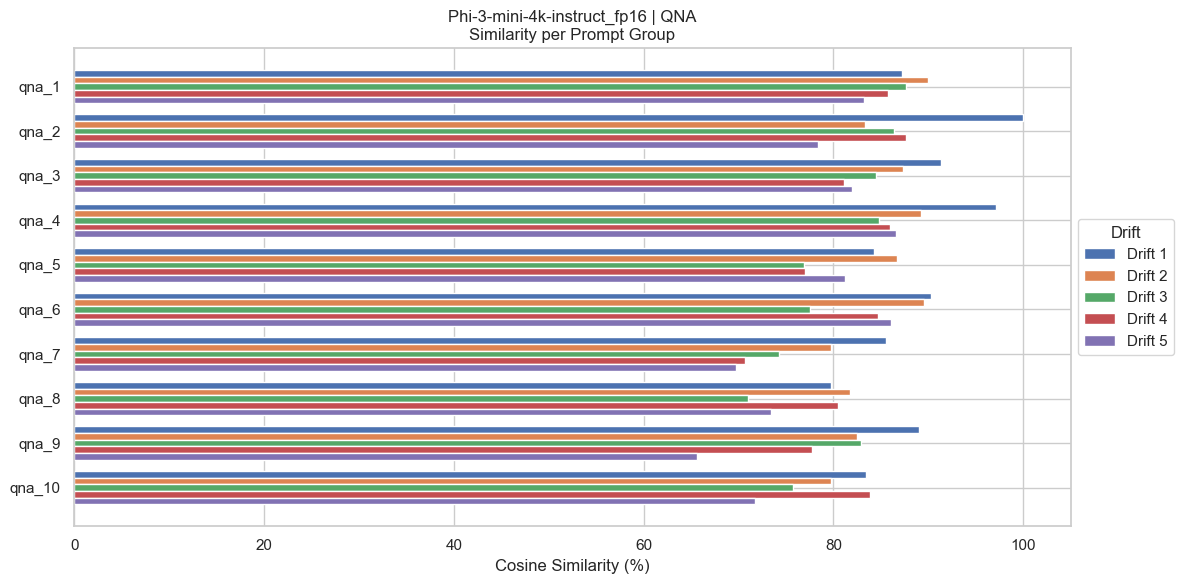

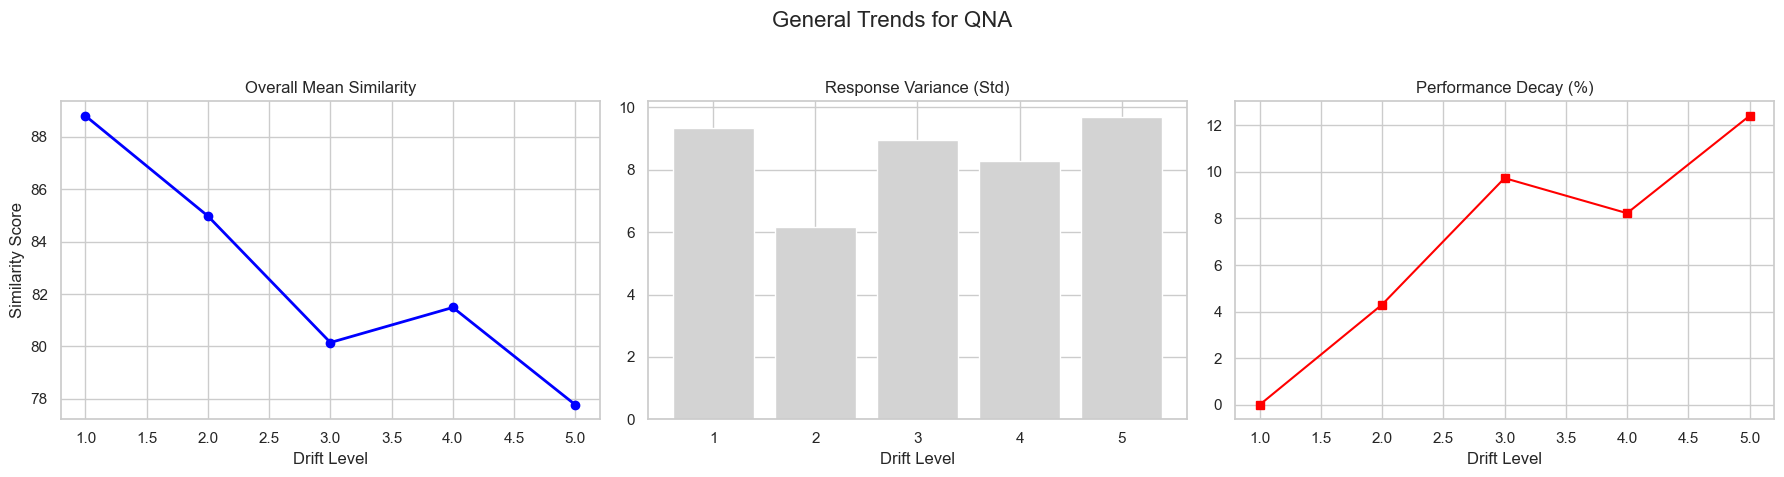

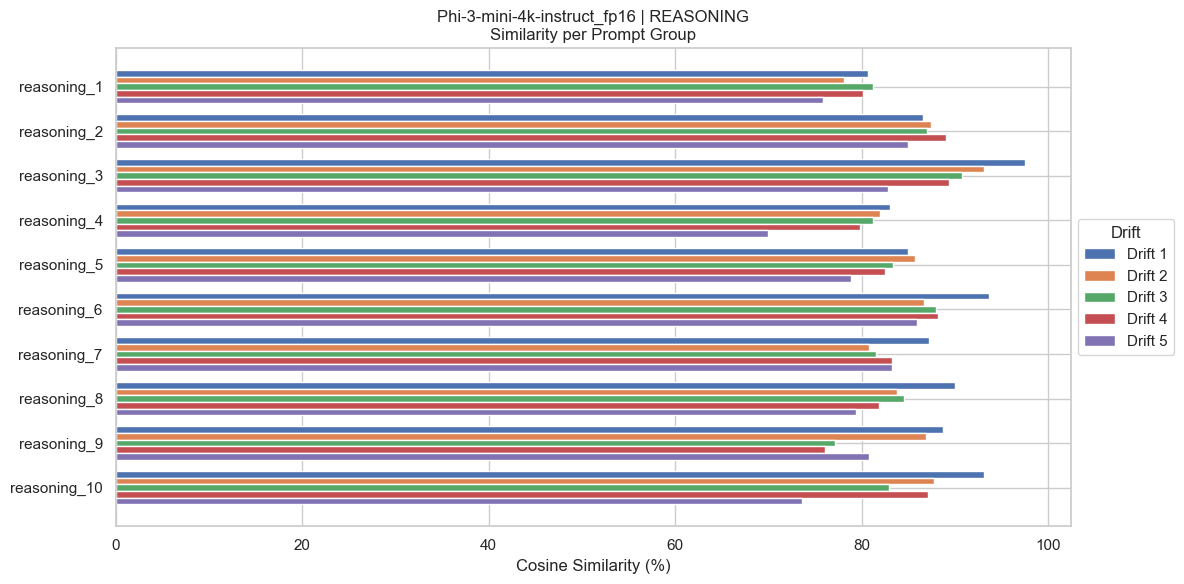

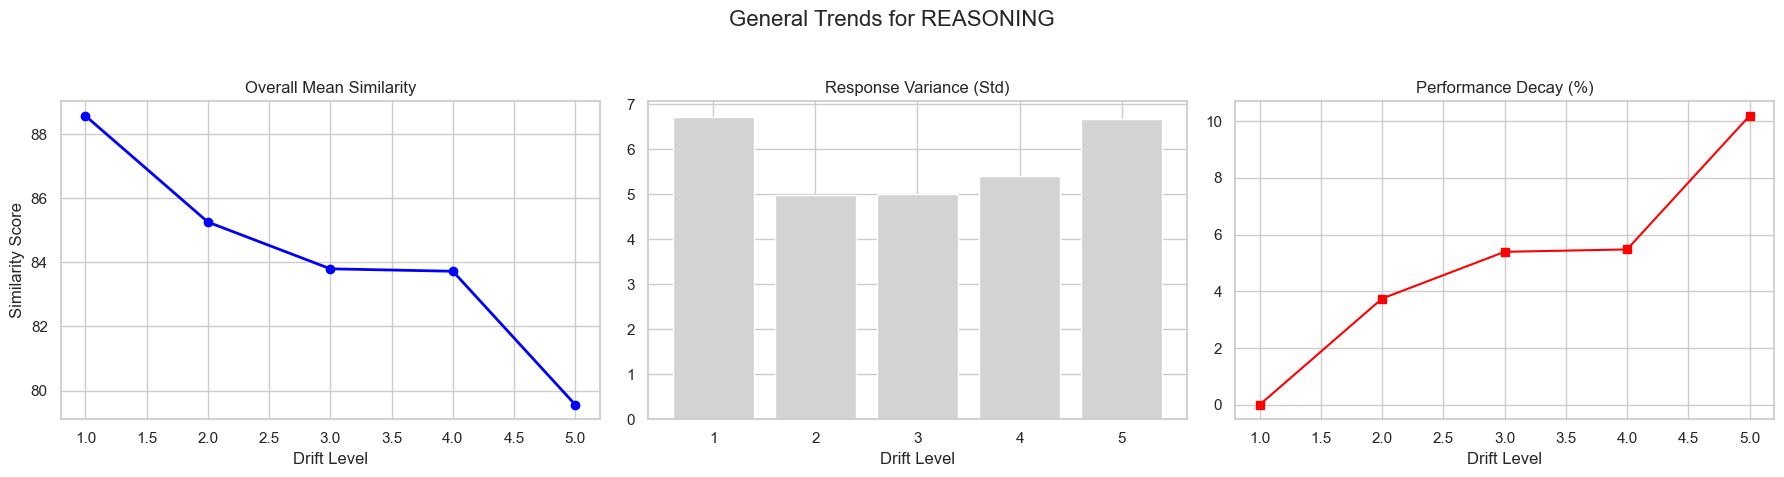


--- Summary Heatmap for Phi-3-mini-4k-instruct_fp16 ---


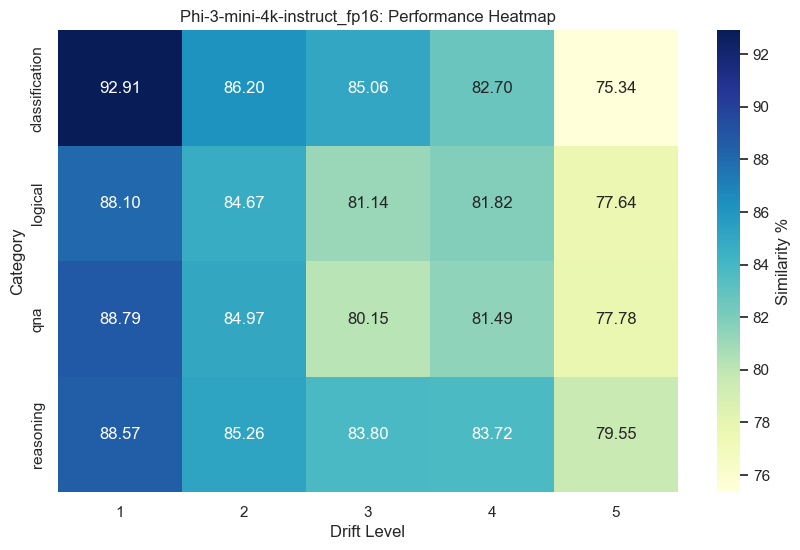


________________________________________________________________________________

##################### MODEL: Mistral-7B-Instruct-v0.2_4bit #####################


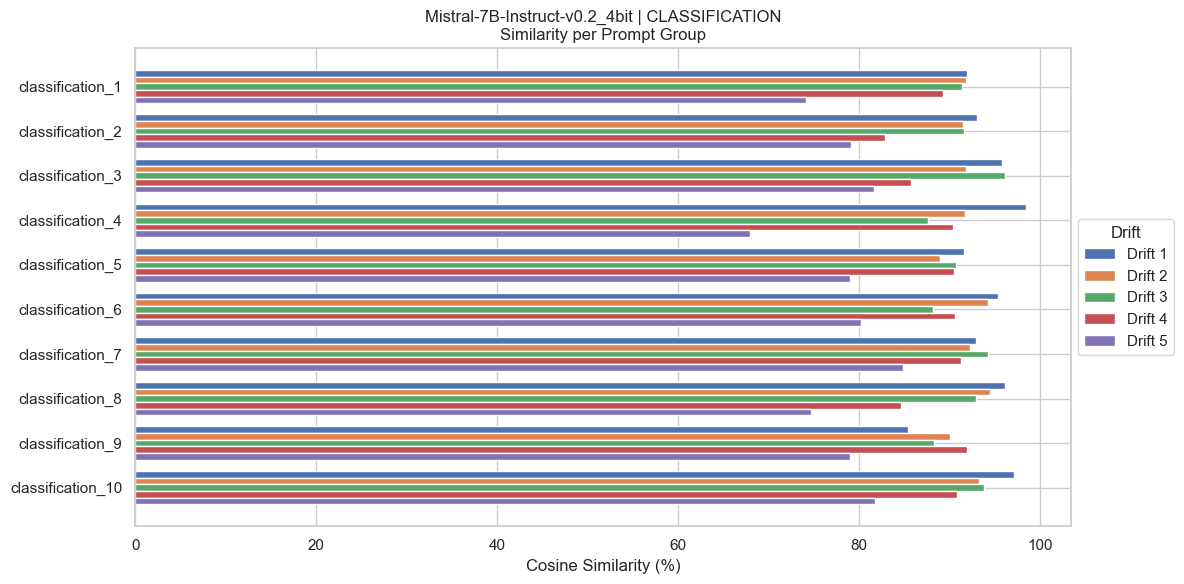

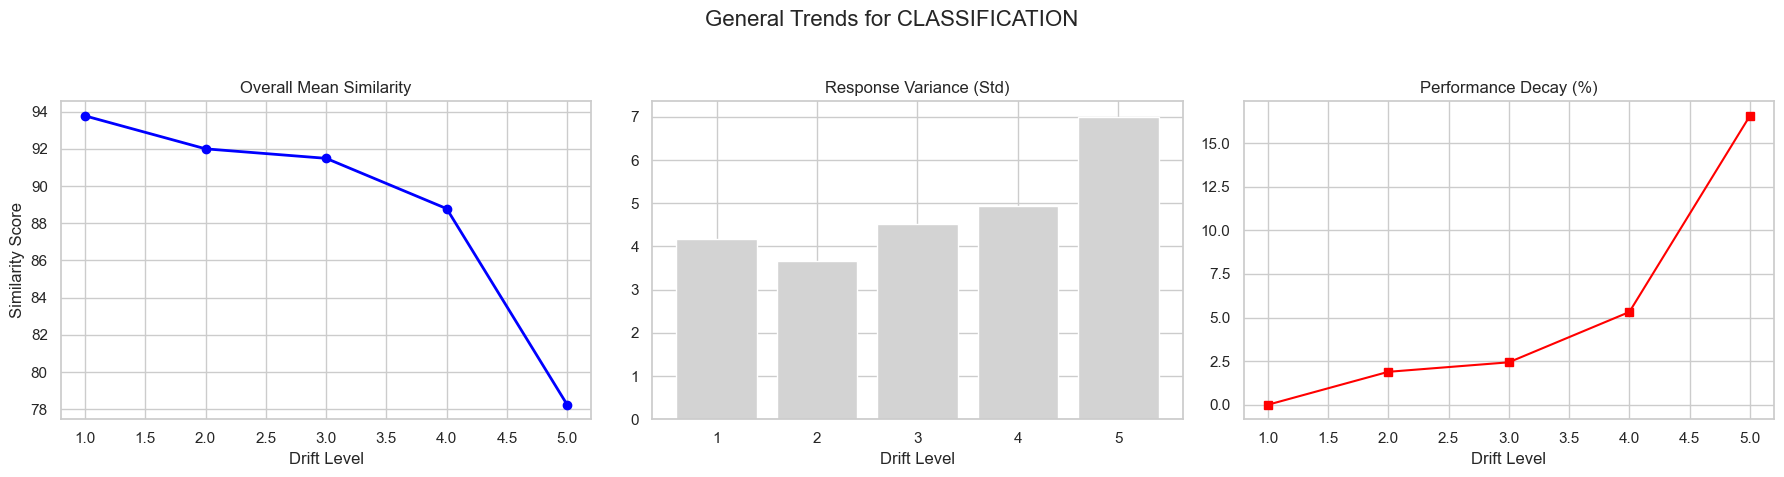

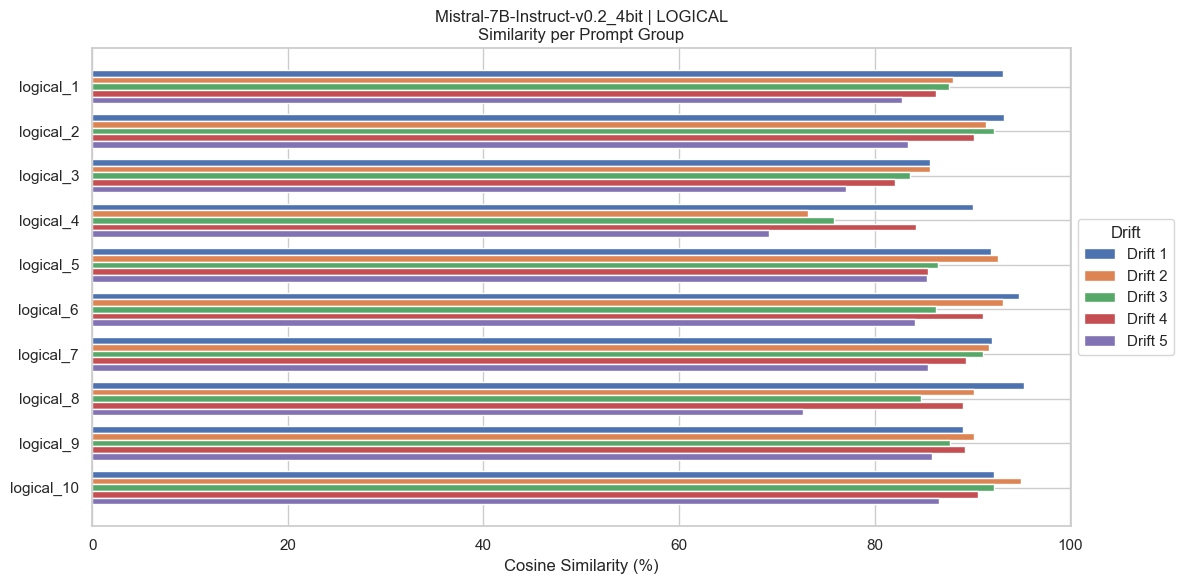

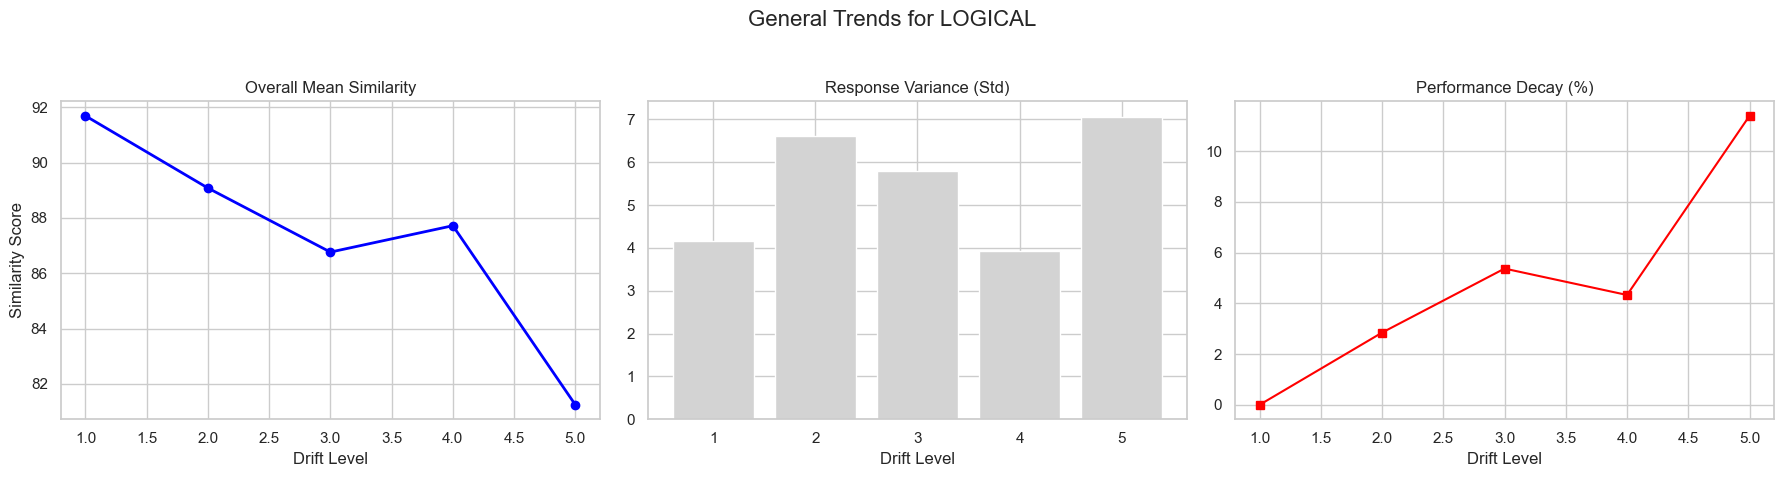

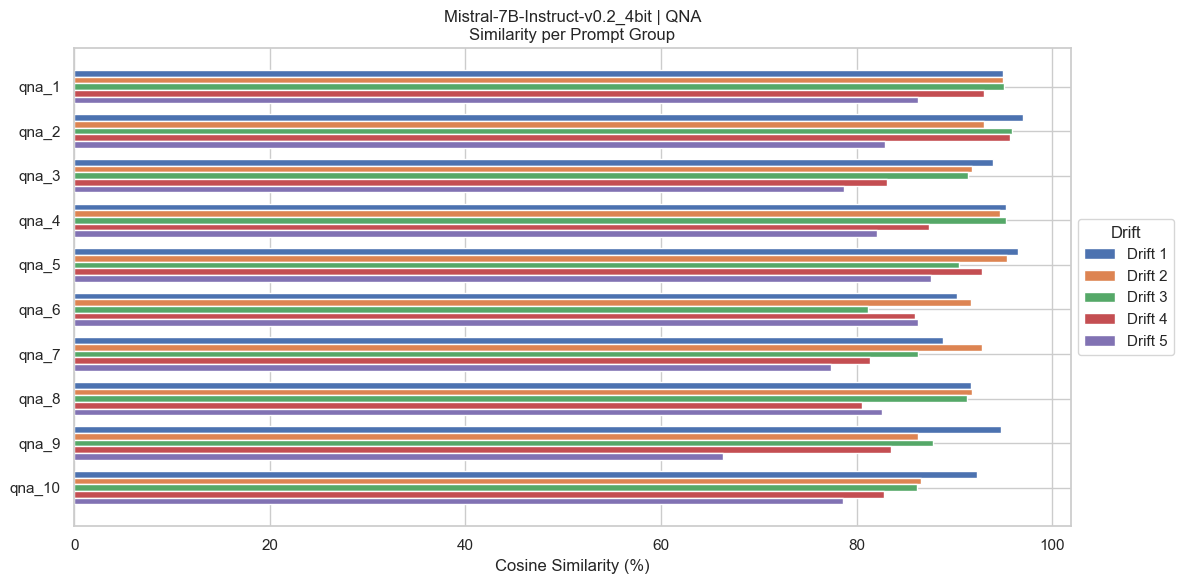

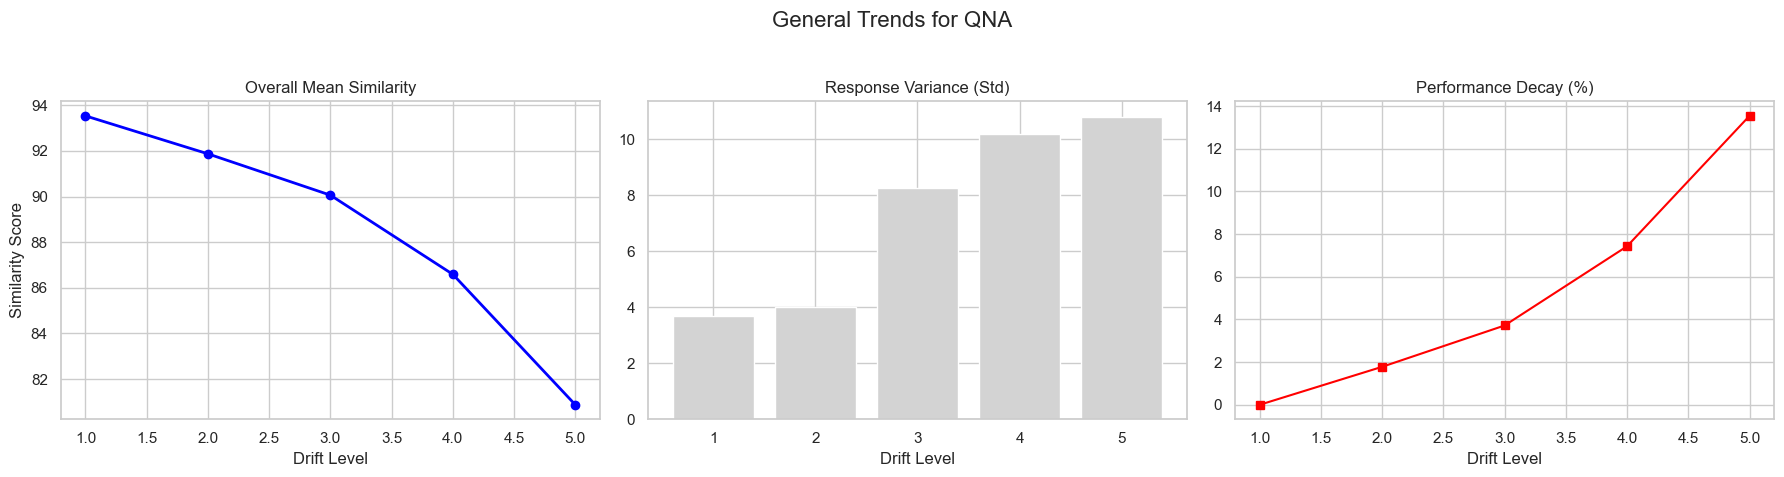

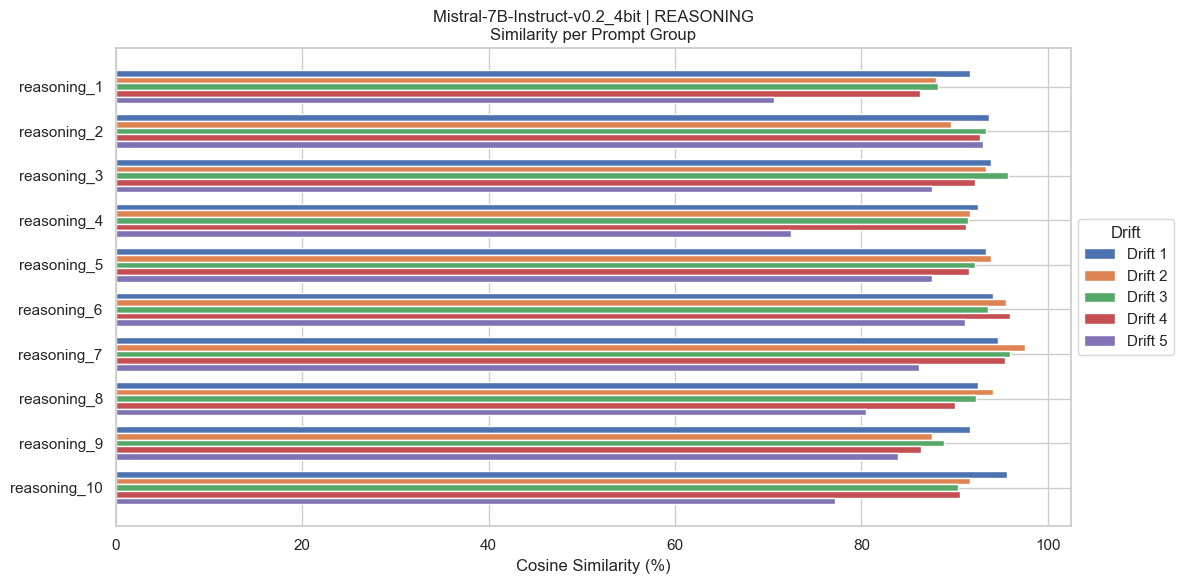

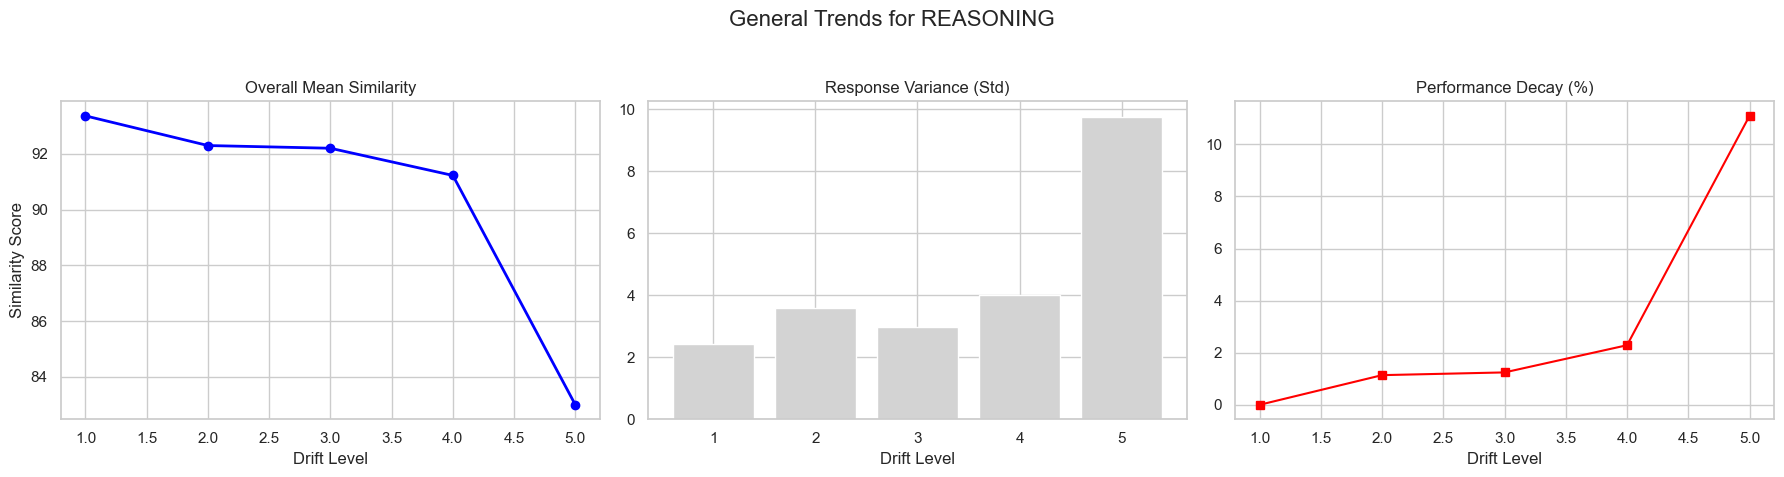


--- Summary Heatmap for Mistral-7B-Instruct-v0.2_4bit ---


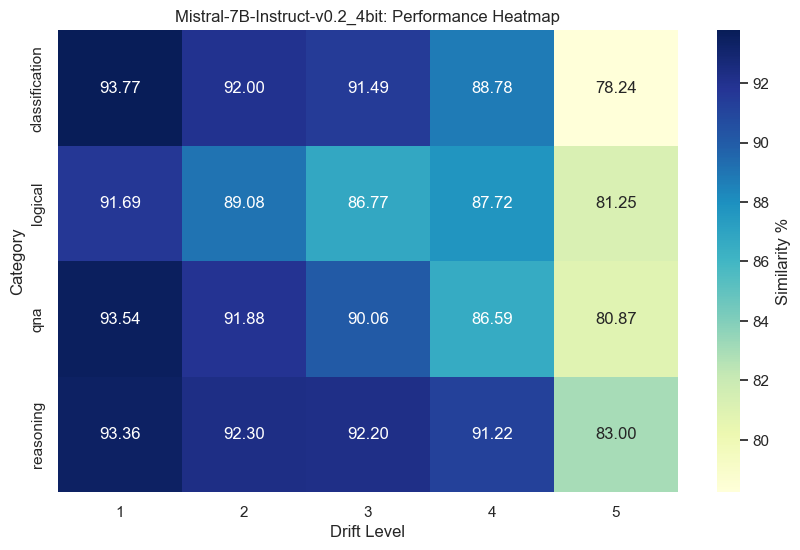


________________________________________________________________________________

##################### MODEL: Mistral-7B-Instruct-v0.2_8bit #####################


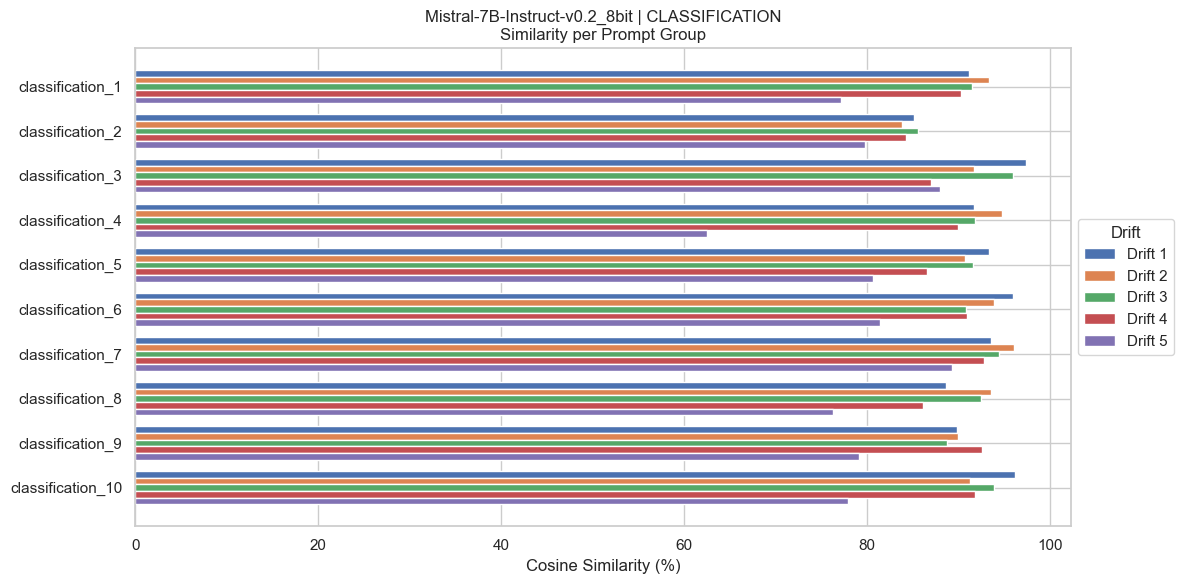

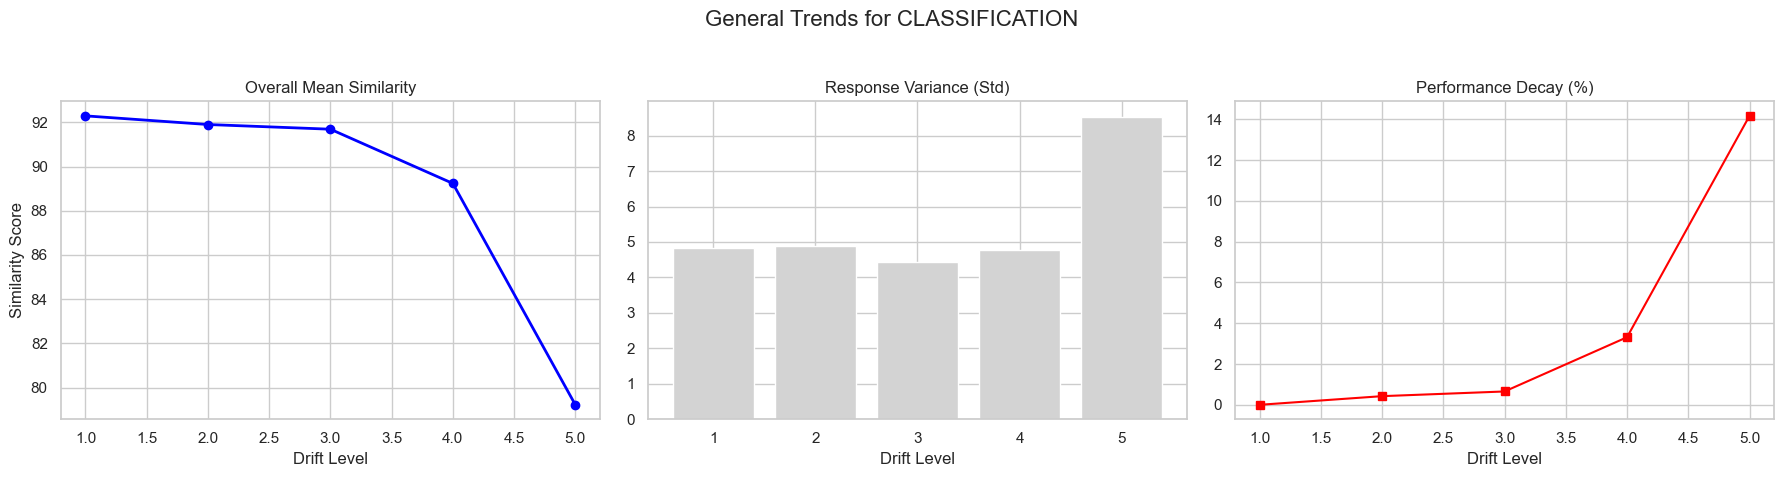

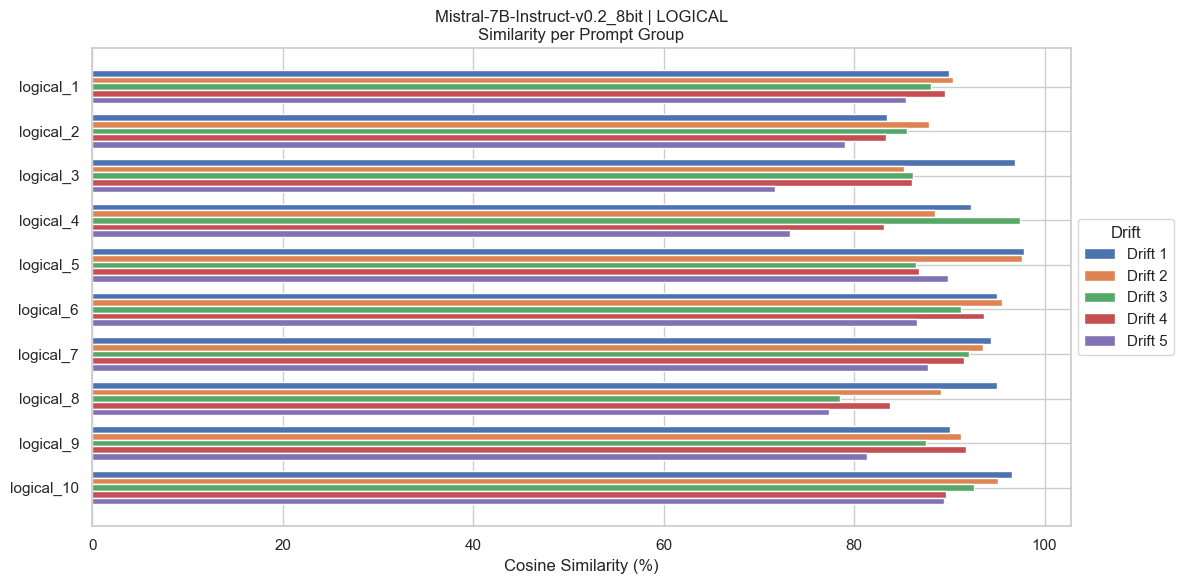

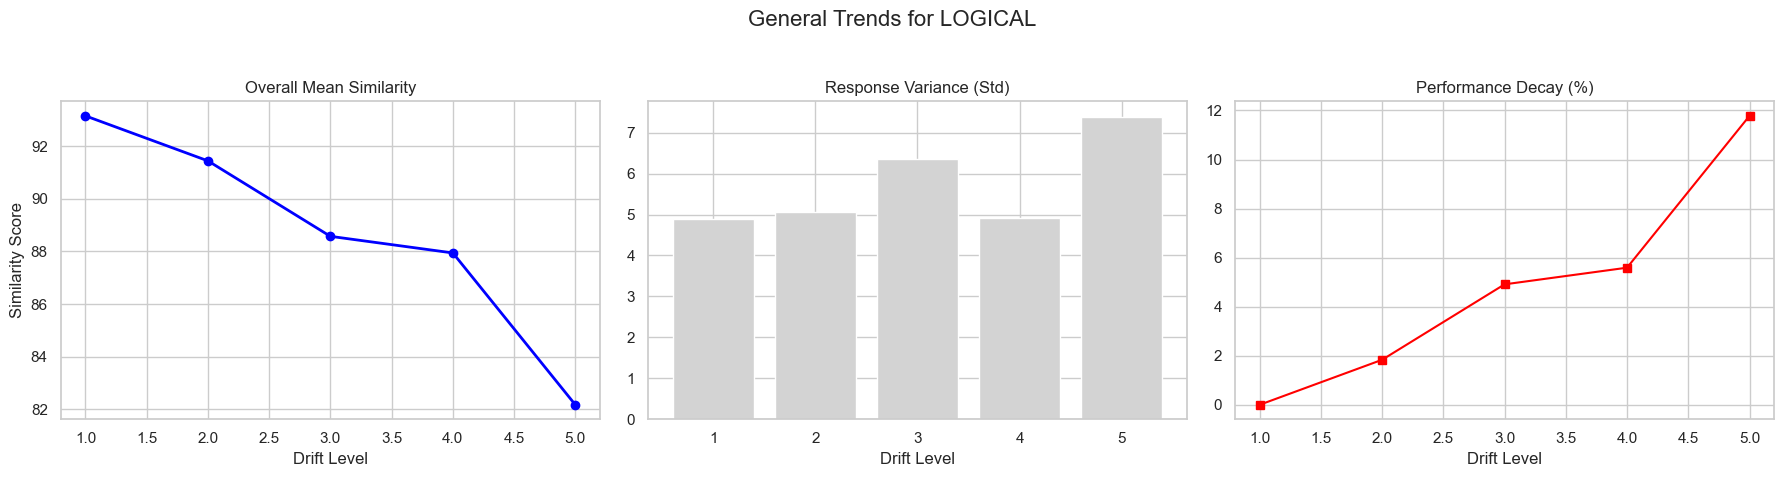

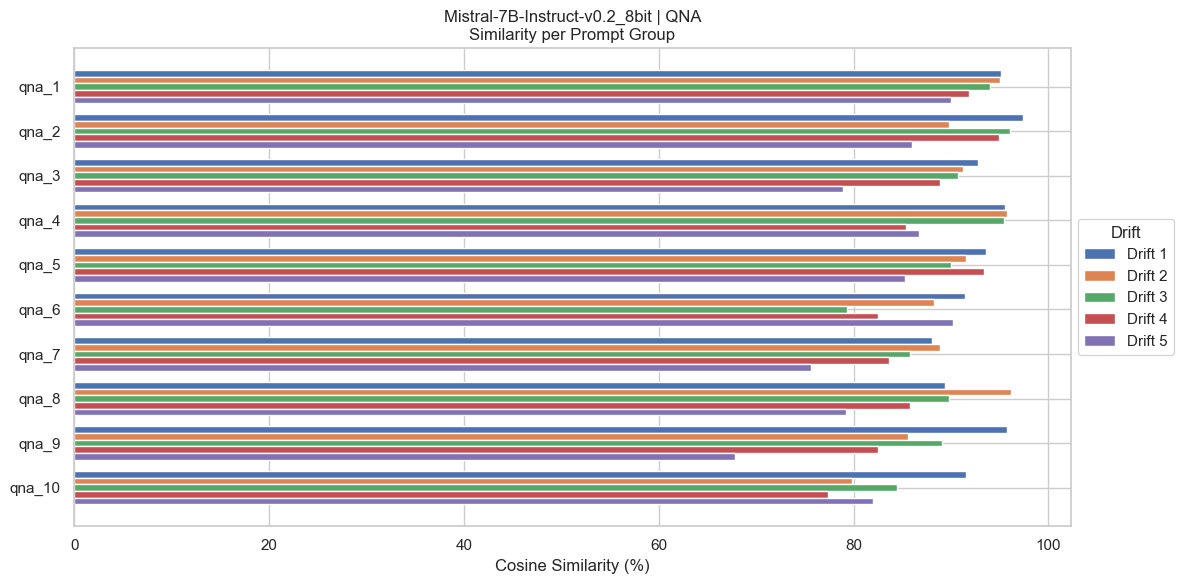

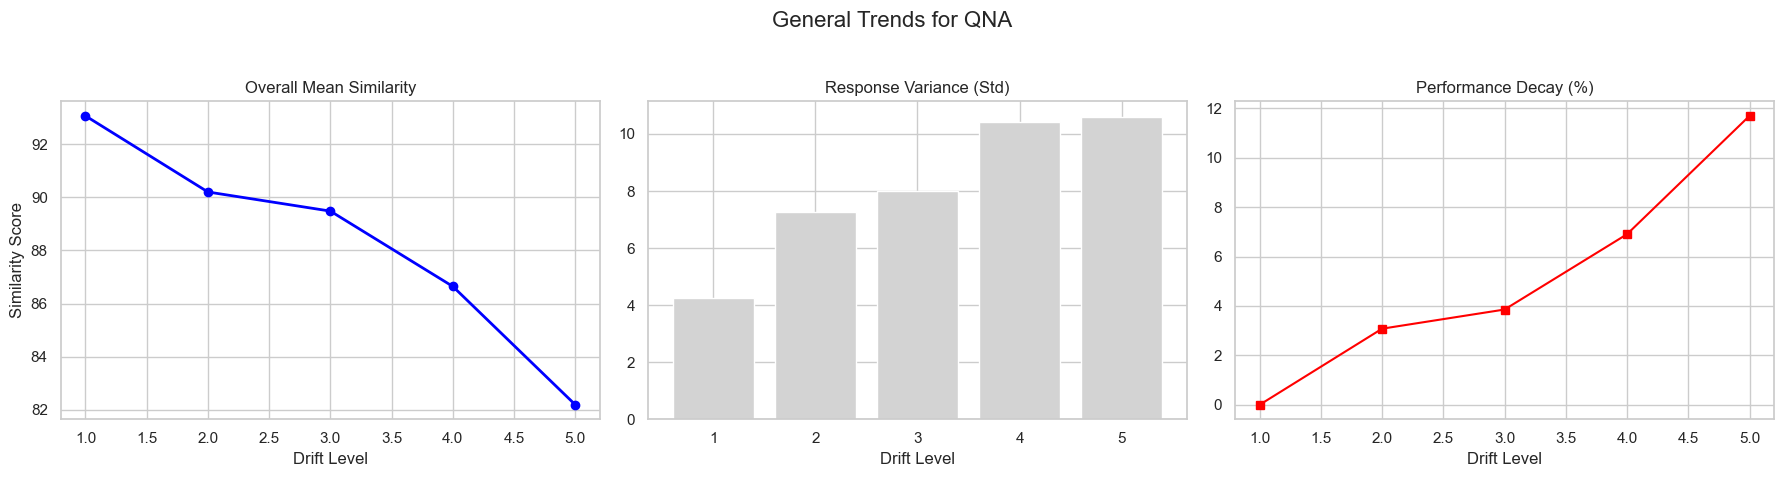

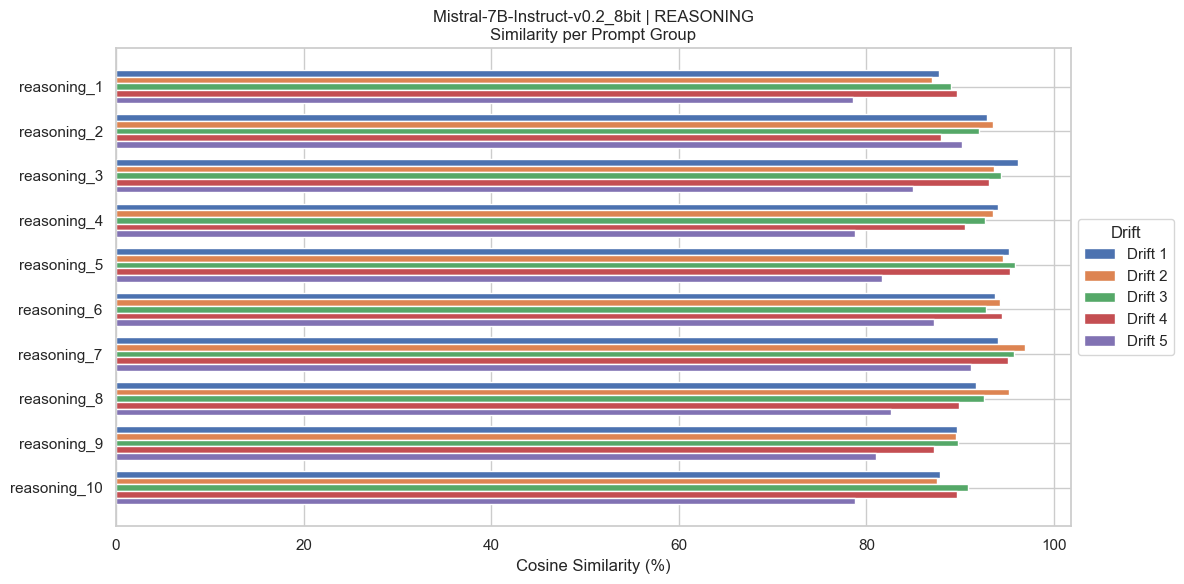

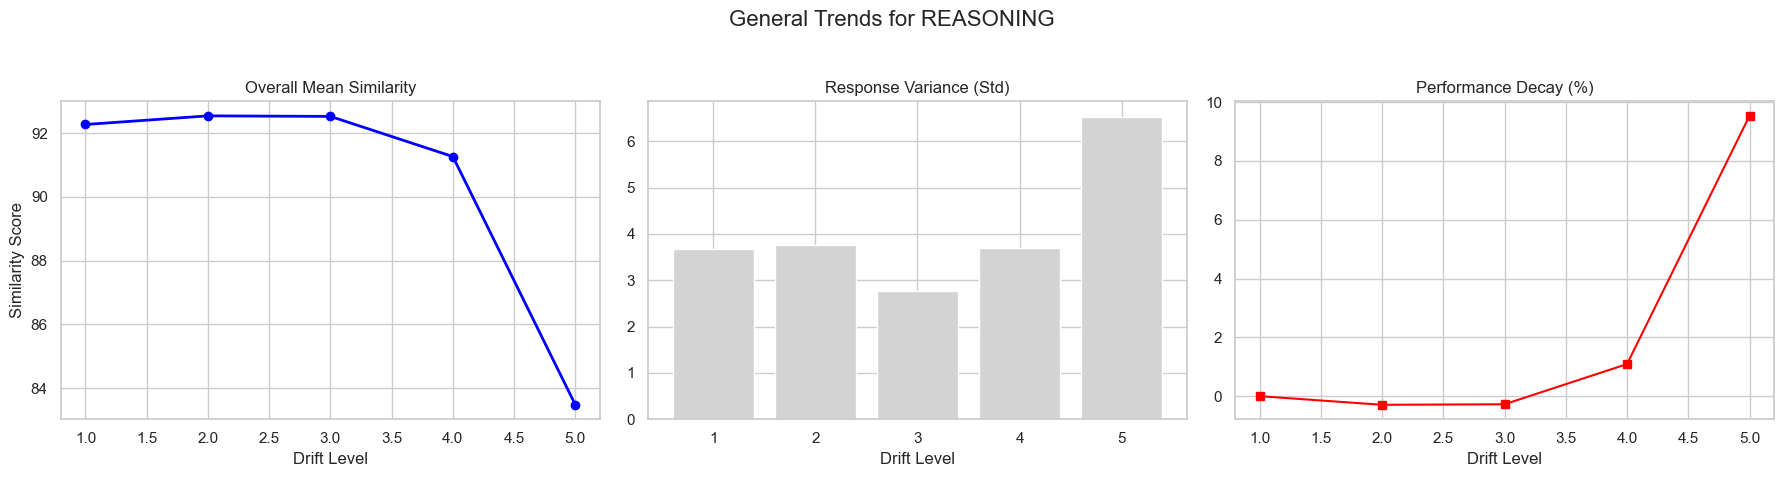


--- Summary Heatmap for Mistral-7B-Instruct-v0.2_8bit ---


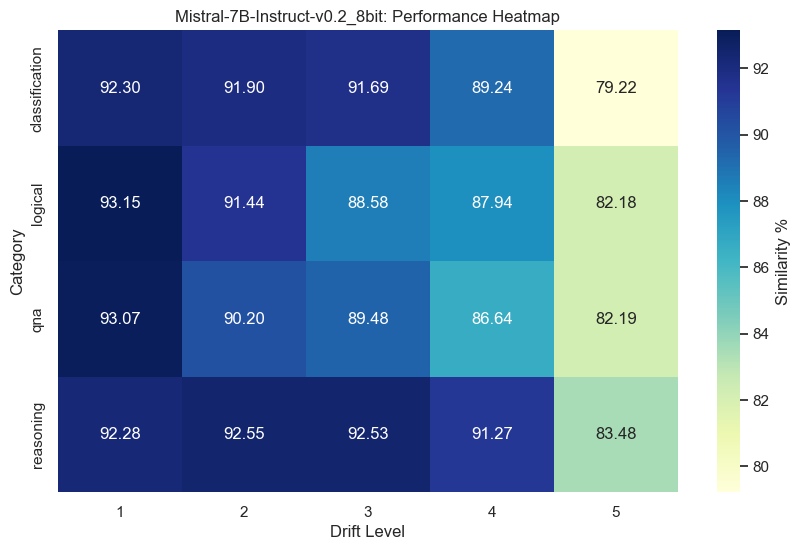


________________________________________________________________________________

##################### MODEL: Mistral-7B-Instruct-v0.2_fp16 #####################


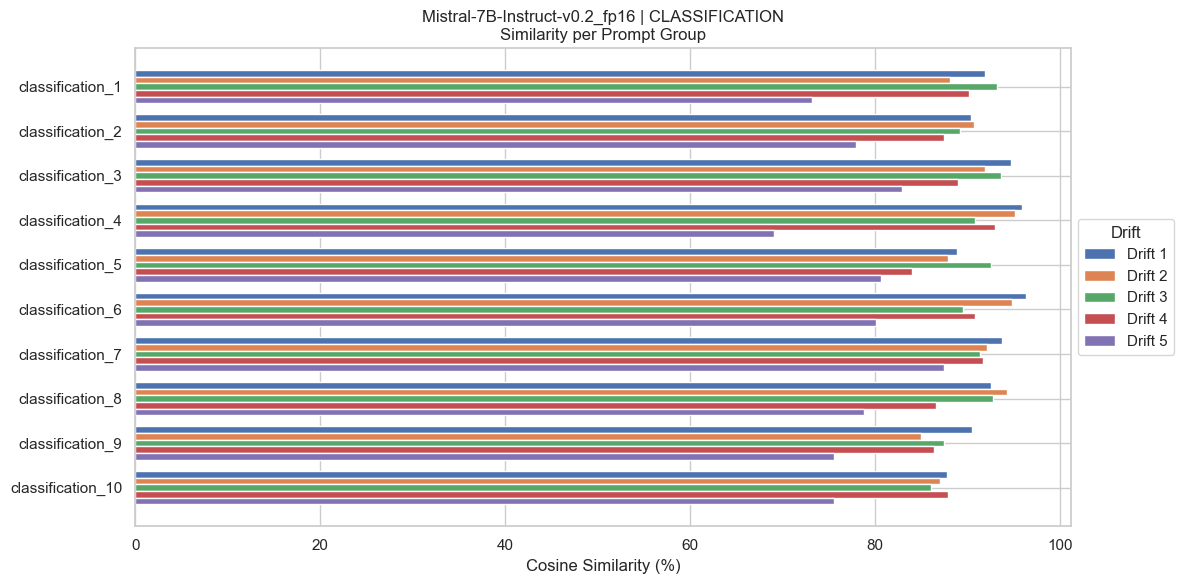

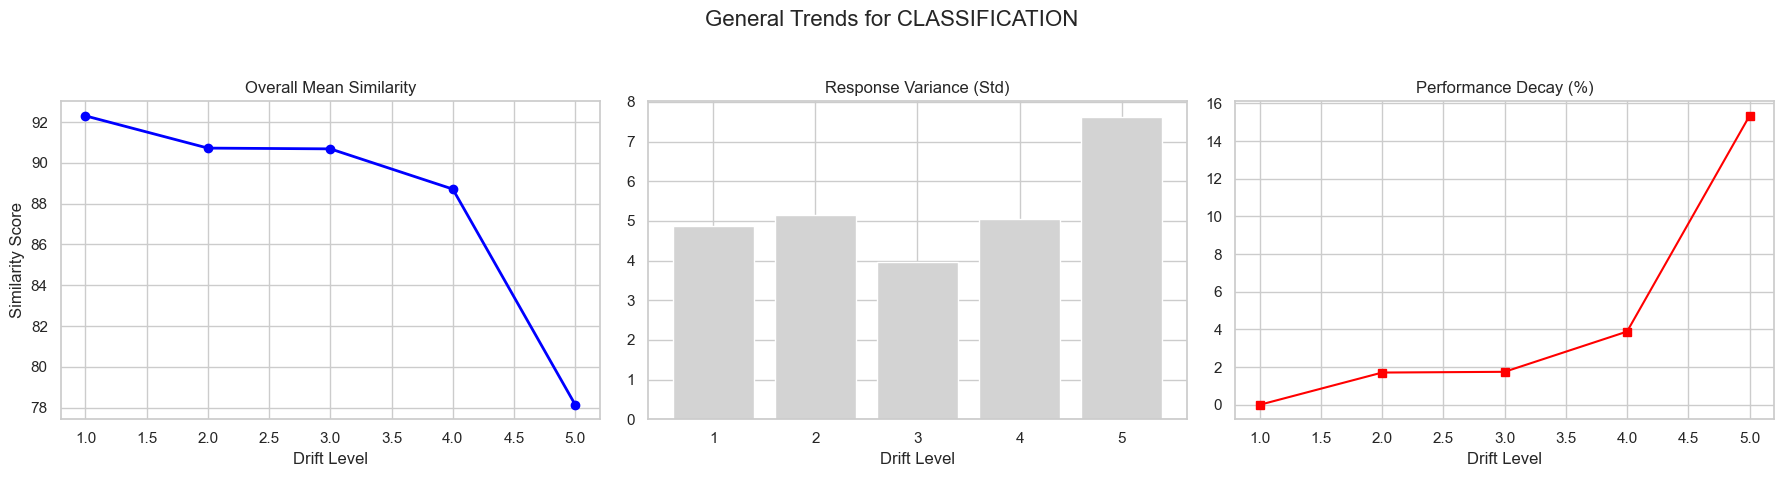

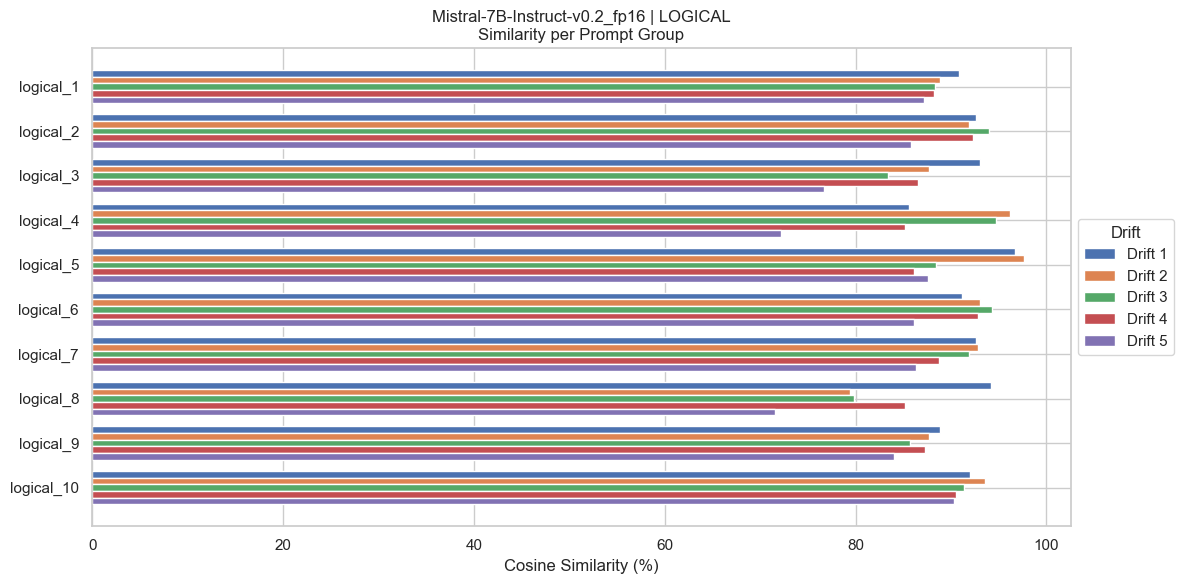

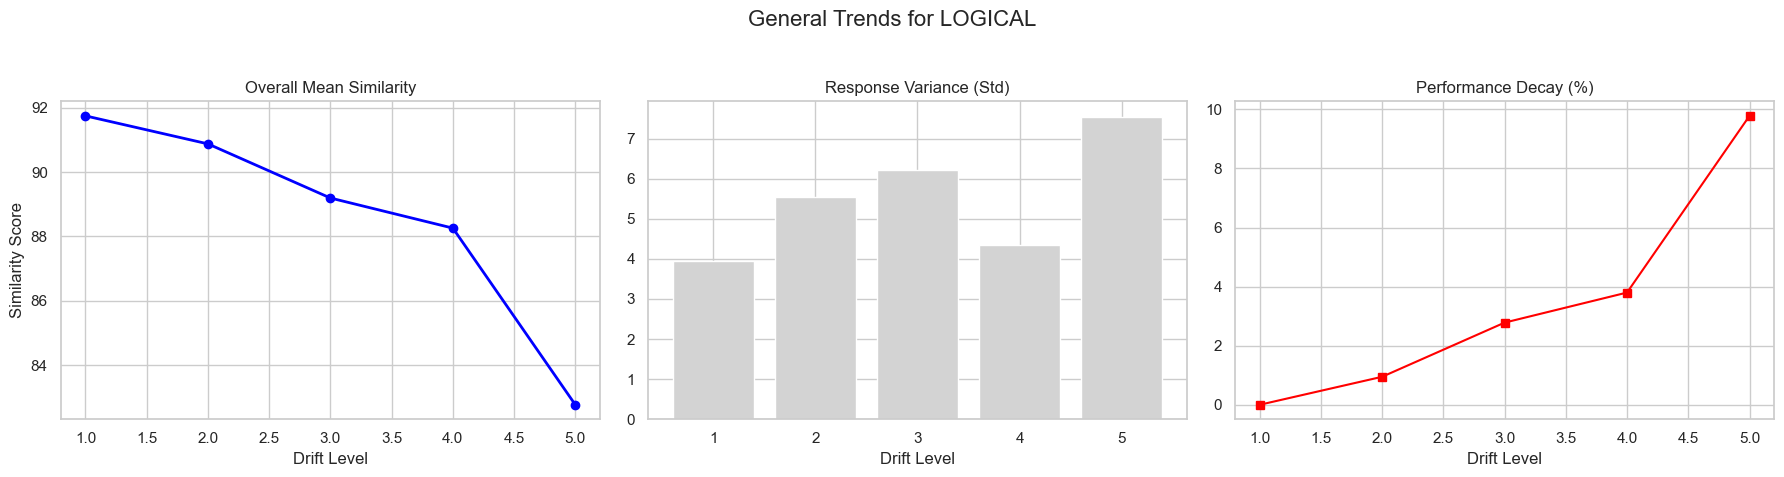

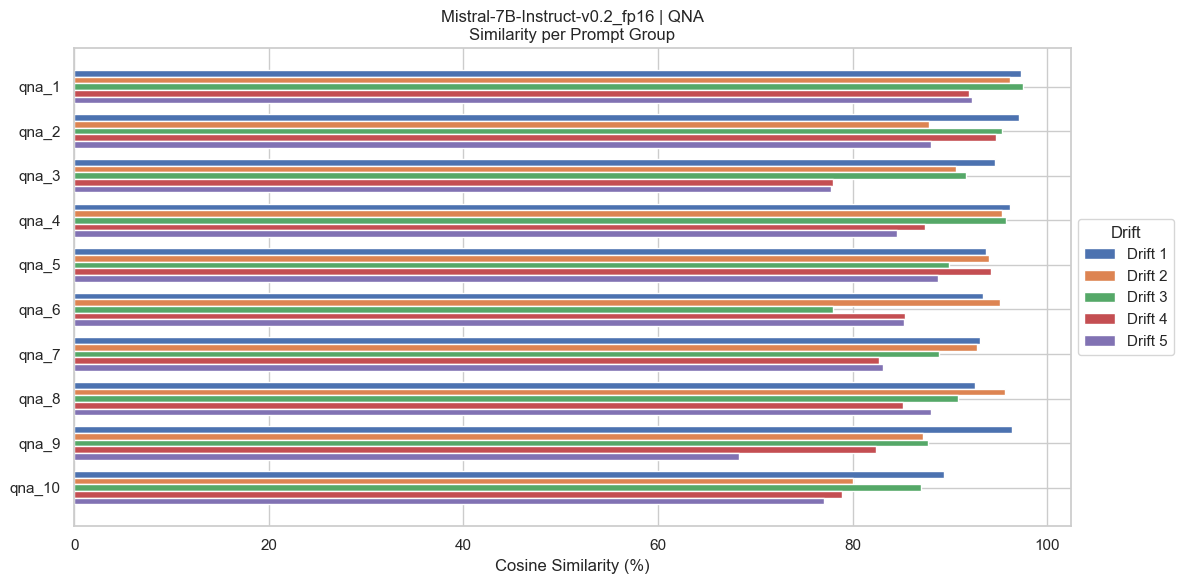

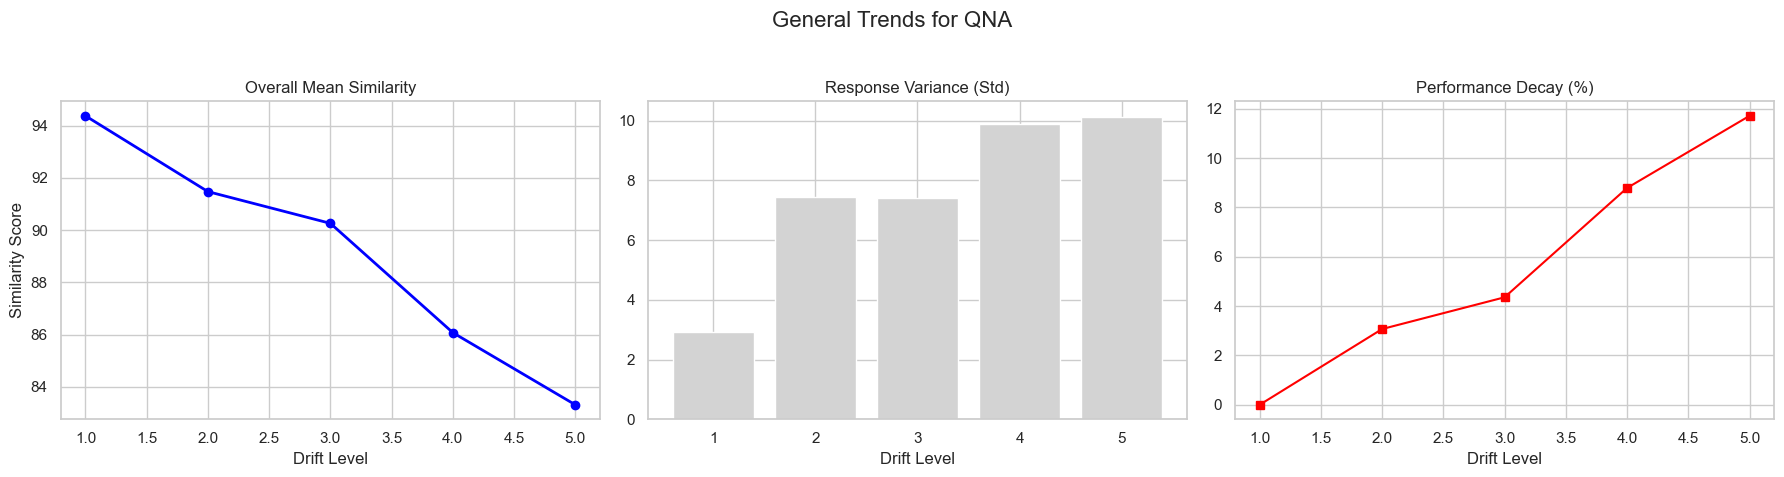

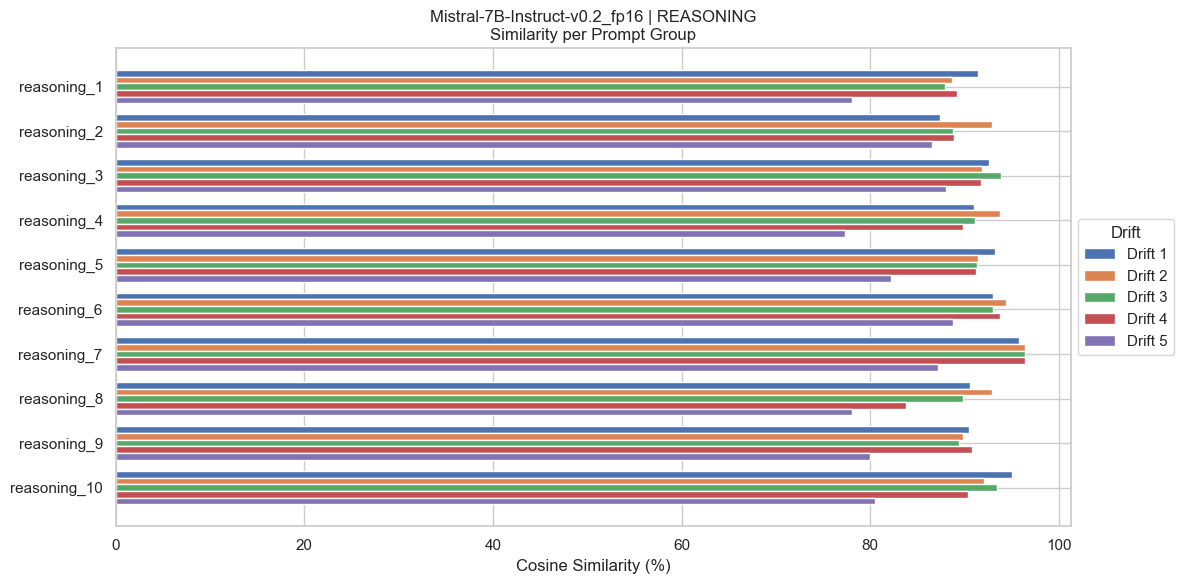

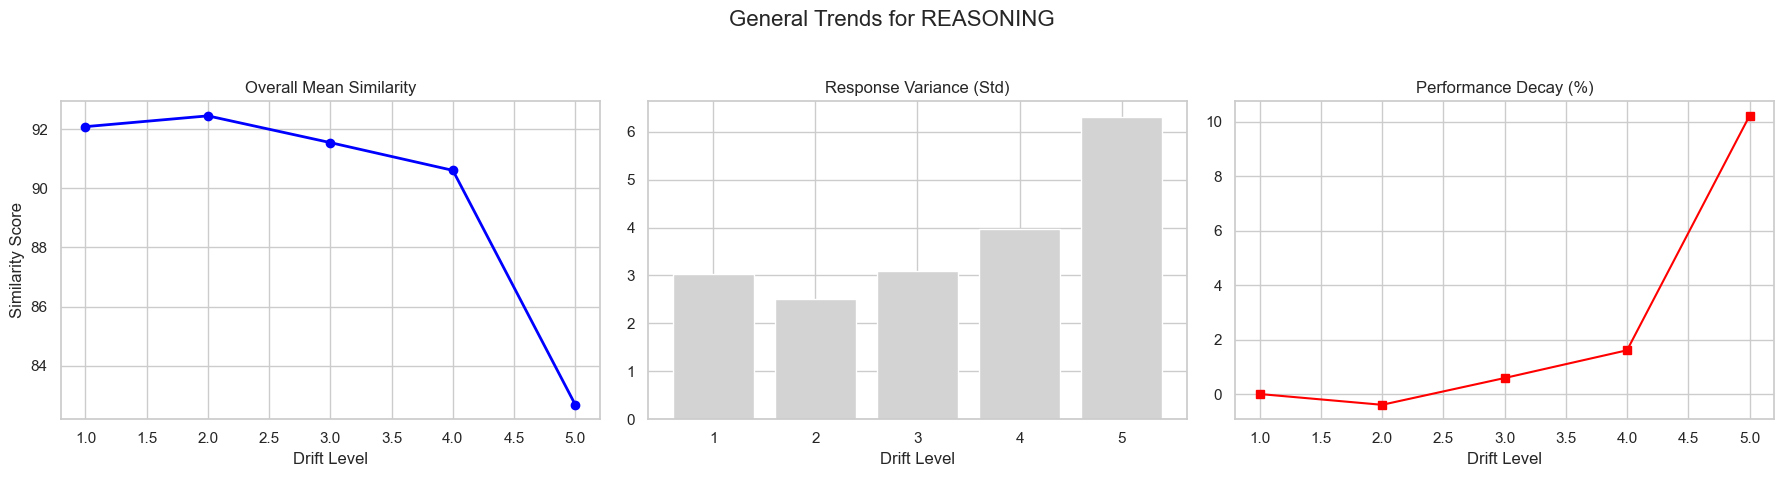


--- Summary Heatmap for Mistral-7B-Instruct-v0.2_fp16 ---


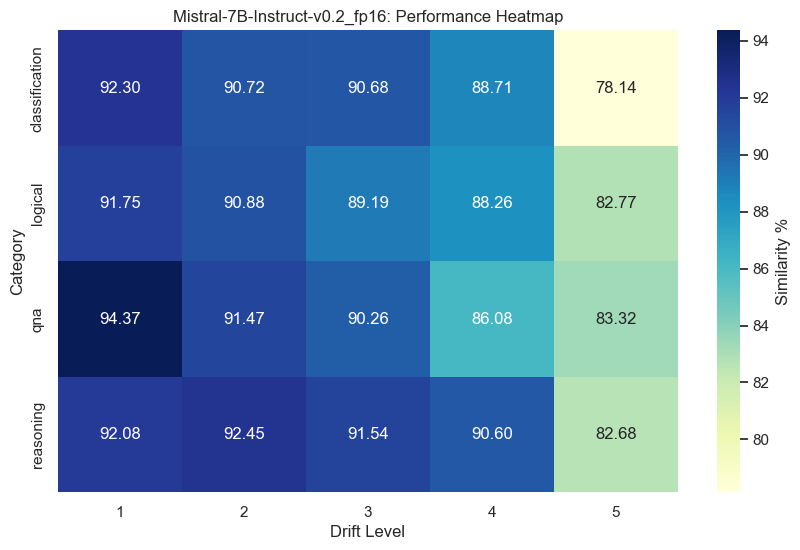


________________________________________________________________________________



In [5]:
run_notebook_visualizer()

################# VISUALIZING: Mistral-7B-Instruct-v0.2 (fp16) #################


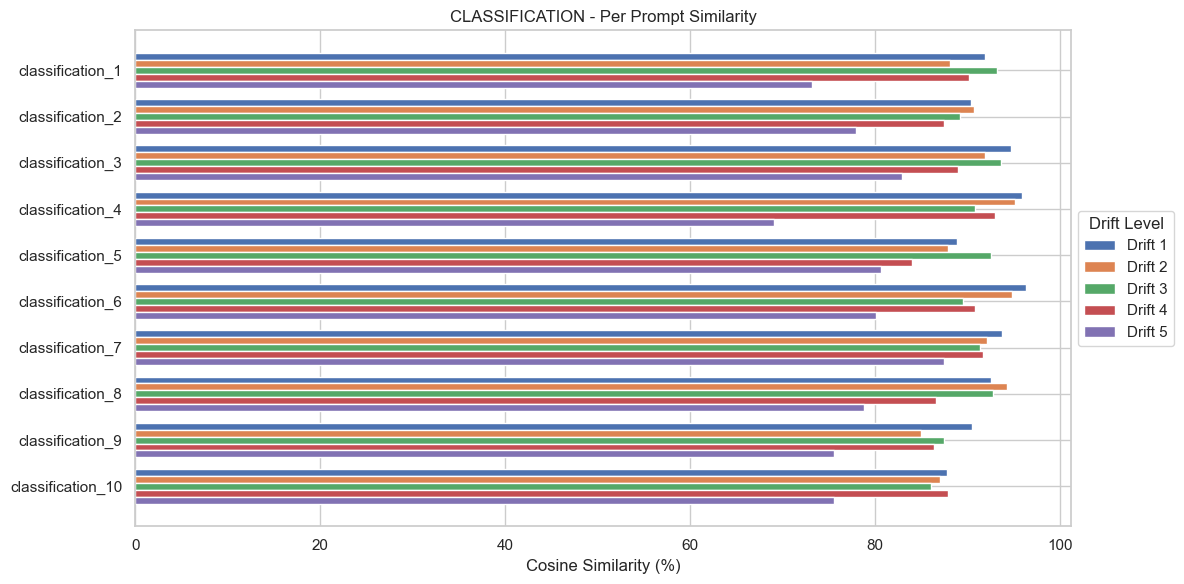

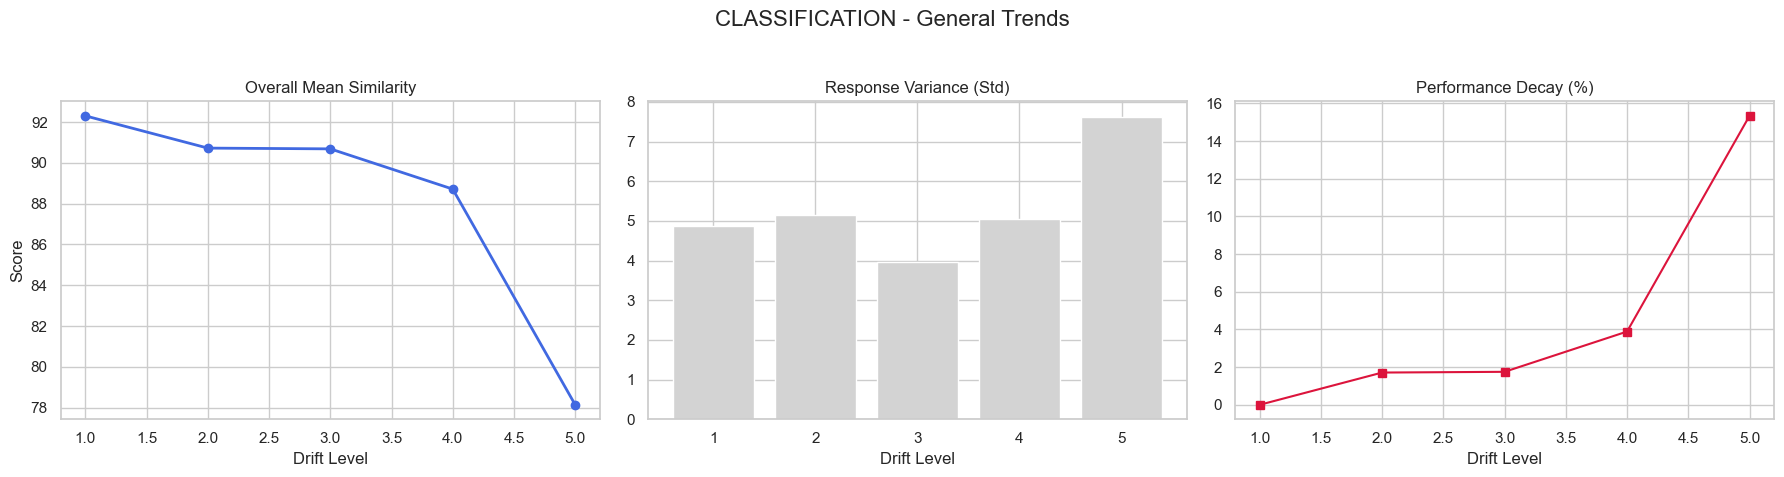

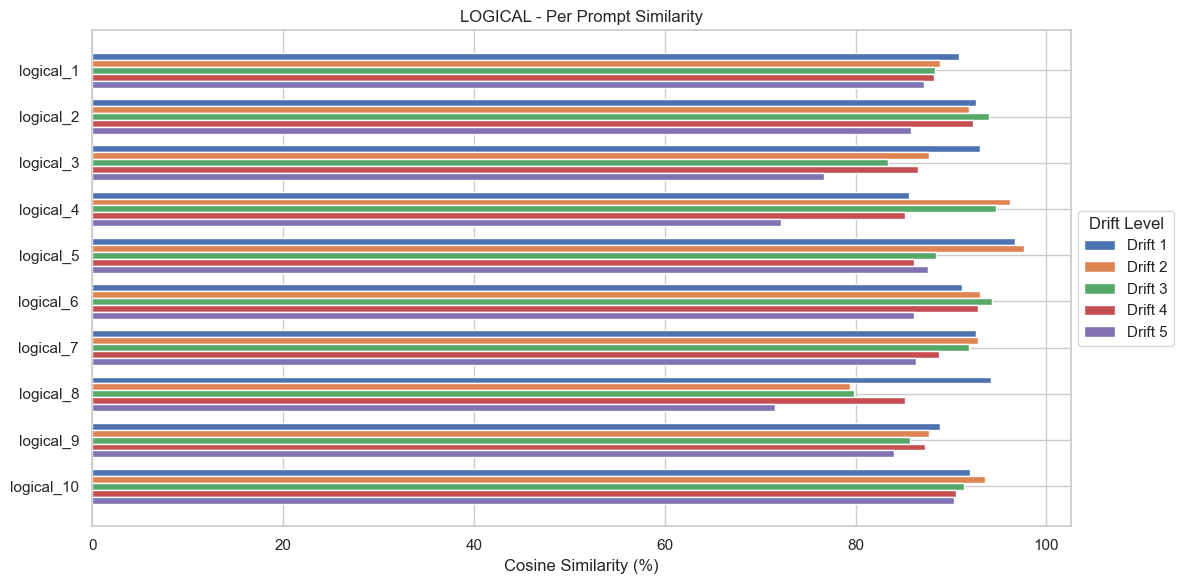

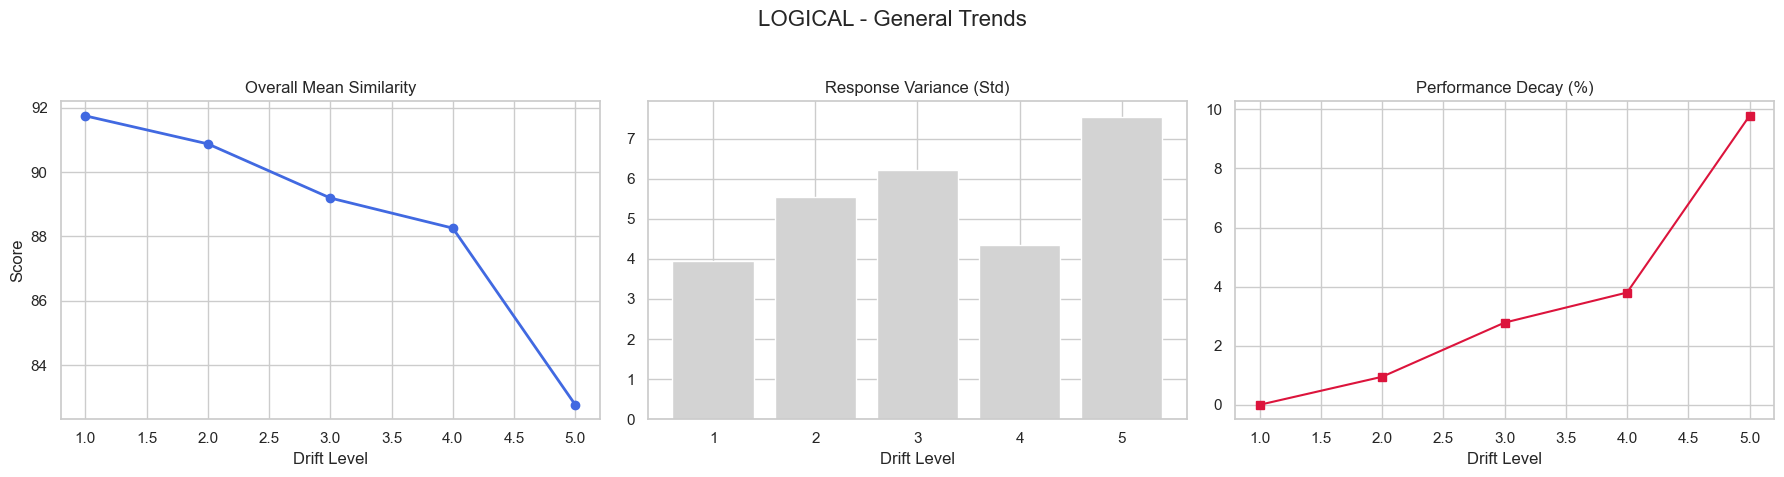

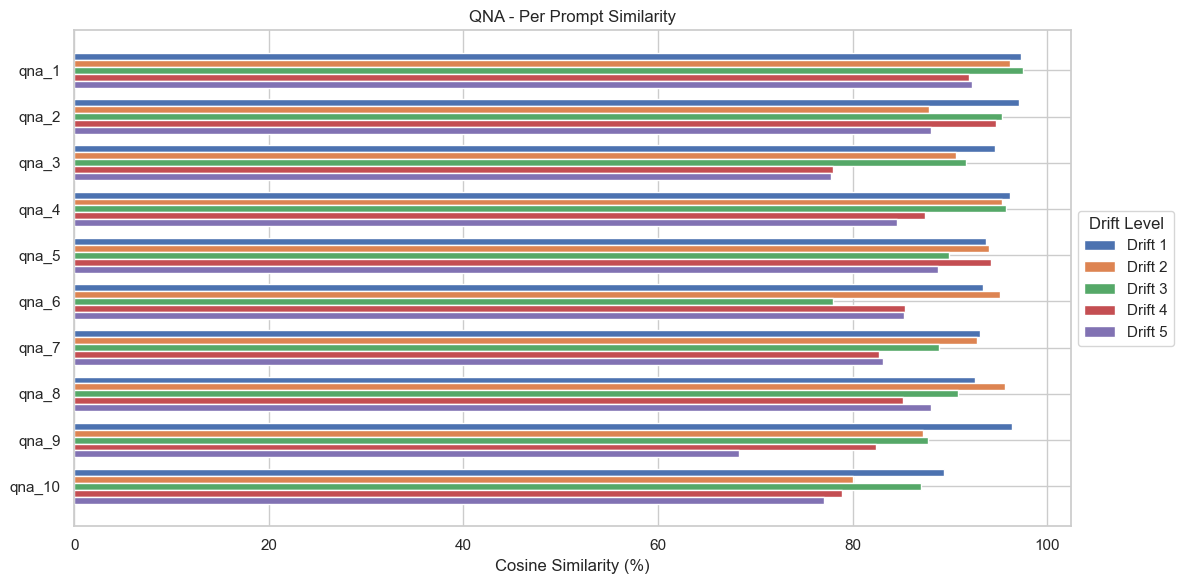

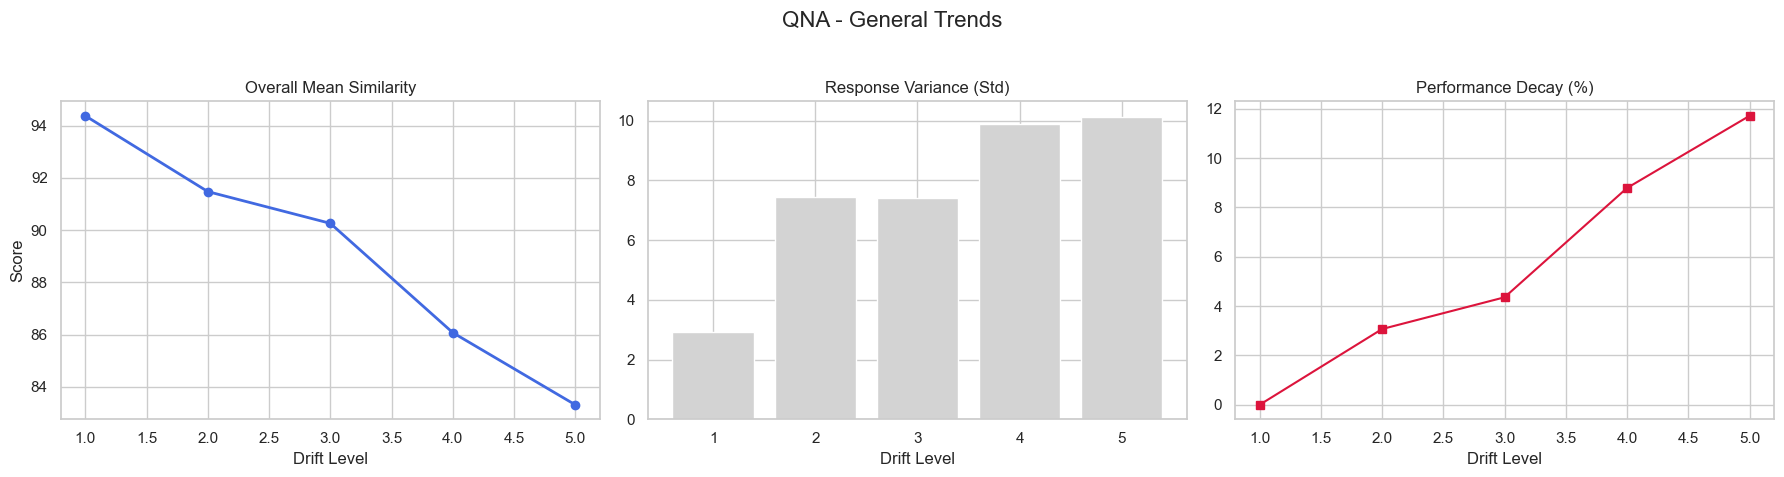

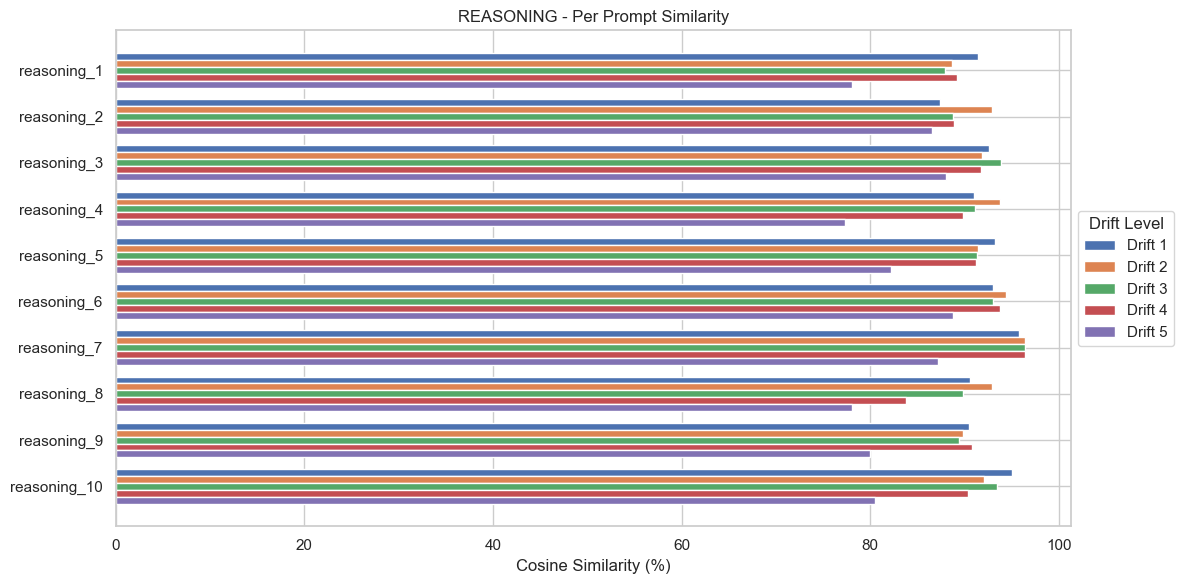

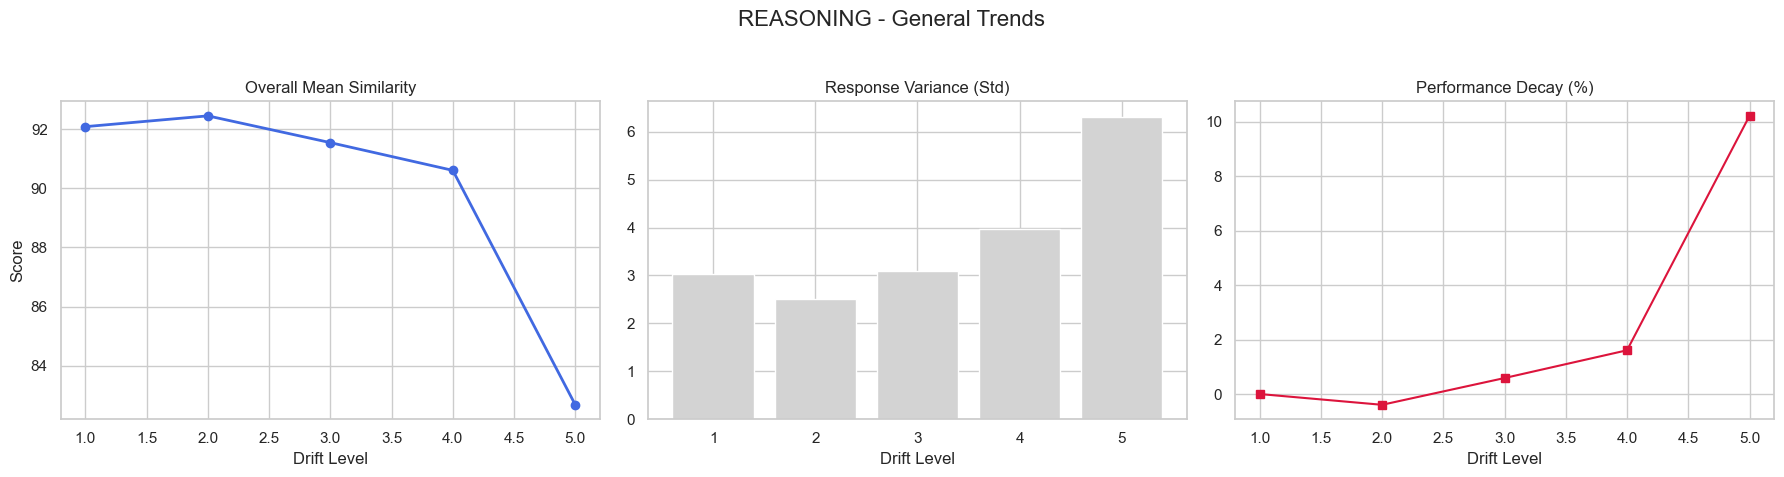


--- Combined Performance Summary Heatmap ---


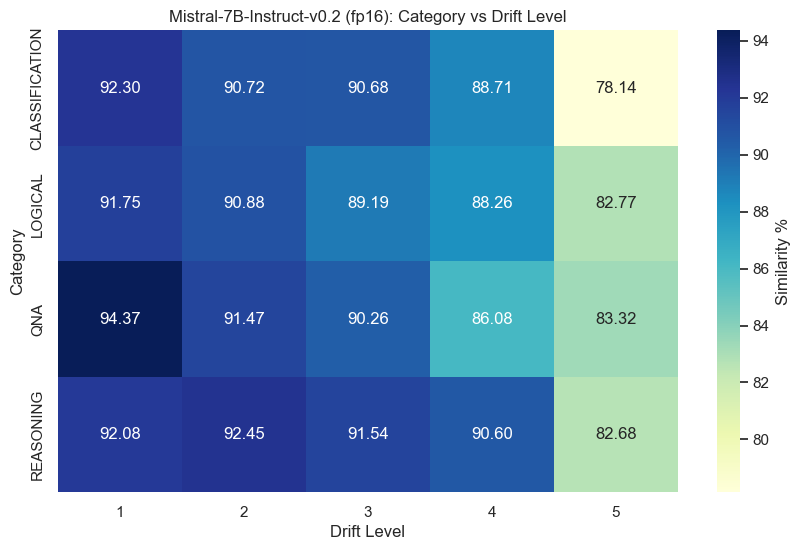

In [6]:
def show_model_stats(provider, model_name, bit):
    """
    Displays visualizations for a specific model configuration.
    Example: show_model_stats("mistralai", "Mistral-7B-Instruct-v0.2", "fp16")
    """
    # Construct the target directory path based on your folder structure
    # Structure: ROOT / provider / model_name_bit / 
    target_folder_name = f"{model_name}_{bit}"
    target_path = os.path.join(INPUT_STATS_BASE, provider, target_folder_name)
    
    if not os.path.exists(target_path):
        print(f"Error: Path not found -> {target_path}")
        print("Check if the provider, model name, or bit type matches your folder names exactly.")
        return

    # Find all category stats files in the target folder
    stats_files = [f for f in os.listdir(target_path) if f.endswith("_stats.csv")]
    
    if not stats_files:
        print(f"No statistics files found in {target_path}")
        return

    print("="*80)
    print(f" VISUALIZING: {model_name} ({bit}) ".center(80, "#"))
    print("="*80)

    category_means = {}

    for file in stats_files:
        file_path = os.path.join(target_path, file)
        df = pd.read_csv(file_path)
        
        # Determine category and drift levels
        category = file.replace("_response_cossim_stats.csv", "").upper()
        drift_col = df.columns[0]
        drift_levels = df[drift_col]

        # ---------------------------------------------------------
        # 1. Detailed Prompt Similarity Bar Chart
        # ---------------------------------------------------------
        mean_cols = [c for c in df.columns if c.endswith("_mean") and "overall" not in c]
        prompt_names = [c.replace("_mean", "") for c in mean_cols]
        data_matrix = np.array([df[col].values for col in mean_cols])
        
        y_pos = np.arange(len(prompt_names))
        bar_height = 0.15

        plt.figure(figsize=(12, 6))
        for i in range(len(drift_levels)):
            plt.barh(y_pos + i * bar_height, data_matrix[:, i], 
                     height=bar_height, label=f"Drift {int(drift_levels[i])}")

        plt.yticks(y_pos + bar_height * 2, prompt_names)
        plt.title(f"{category} - Per Prompt Similarity")
        plt.xlabel("Cosine Similarity (%)")
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Drift Level")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------
        # 2. Category Trend Summary (Mean, Std, Decay)
        # ---------------------------------------------------------
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Overall Mean
        axes[0].plot(drift_levels, df["overall_mean"], marker="o", color="royalblue", linewidth=2)
        axes[0].set_title("Overall Mean Similarity")
        axes[0].set_xlabel("Drift Level")
        axes[0].set_ylabel("Score")

        # Response Variance
        axes[1].bar(drift_levels, df["overall_std"], color="lightgray")
        axes[1].set_title("Response Variance (Std)")
        axes[1].set_xlabel("Drift Level")

        # Performance Decay
        axes[2].plot(drift_levels, df["relative_drop_%"], marker="s", color="crimson")
        axes[2].set_title("Performance Decay (%)")
        axes[2].set_xlabel("Drift Level")

        plt.suptitle(f"{category} - General Trends", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        category_means[category] = df["overall_mean"].values

    # ---------------------------------------------------------
    # 3. Model-wide Summary Heatmap
    # ---------------------------------------------------------
    if category_means:
        print(f"\n--- Combined Performance Summary Heatmap ---")
        heatmap_df = pd.DataFrame(category_means, index=[1, 2, 3, 4, 5])
        plt.figure(figsize=(10, 6))
        sns.heatmap(heatmap_df.T, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Similarity %'})
        plt.title(f"{model_name} ({bit}): Category vs Drift Level")
        plt.xlabel("Drift Level")
        plt.ylabel("Category")
        plt.show()

# --- Example Usage ---
show_model_stats("mistralai", "Mistral-7B-Instruct-v0.2", "fp16")